In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
"""Definimos las direcciones de los archivos"""

dira001 = "./data/var_alpha/alpha_0.01/"
dira1 = "./data/var_alpha/alpha_1/"
dira20 = "./data/var_alpha/alpha_20/"
dira50 = "./data/var_alpha/alpha_50/"
dira100 = "./data/var_alpha/alpha_100/"

q = 5050

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

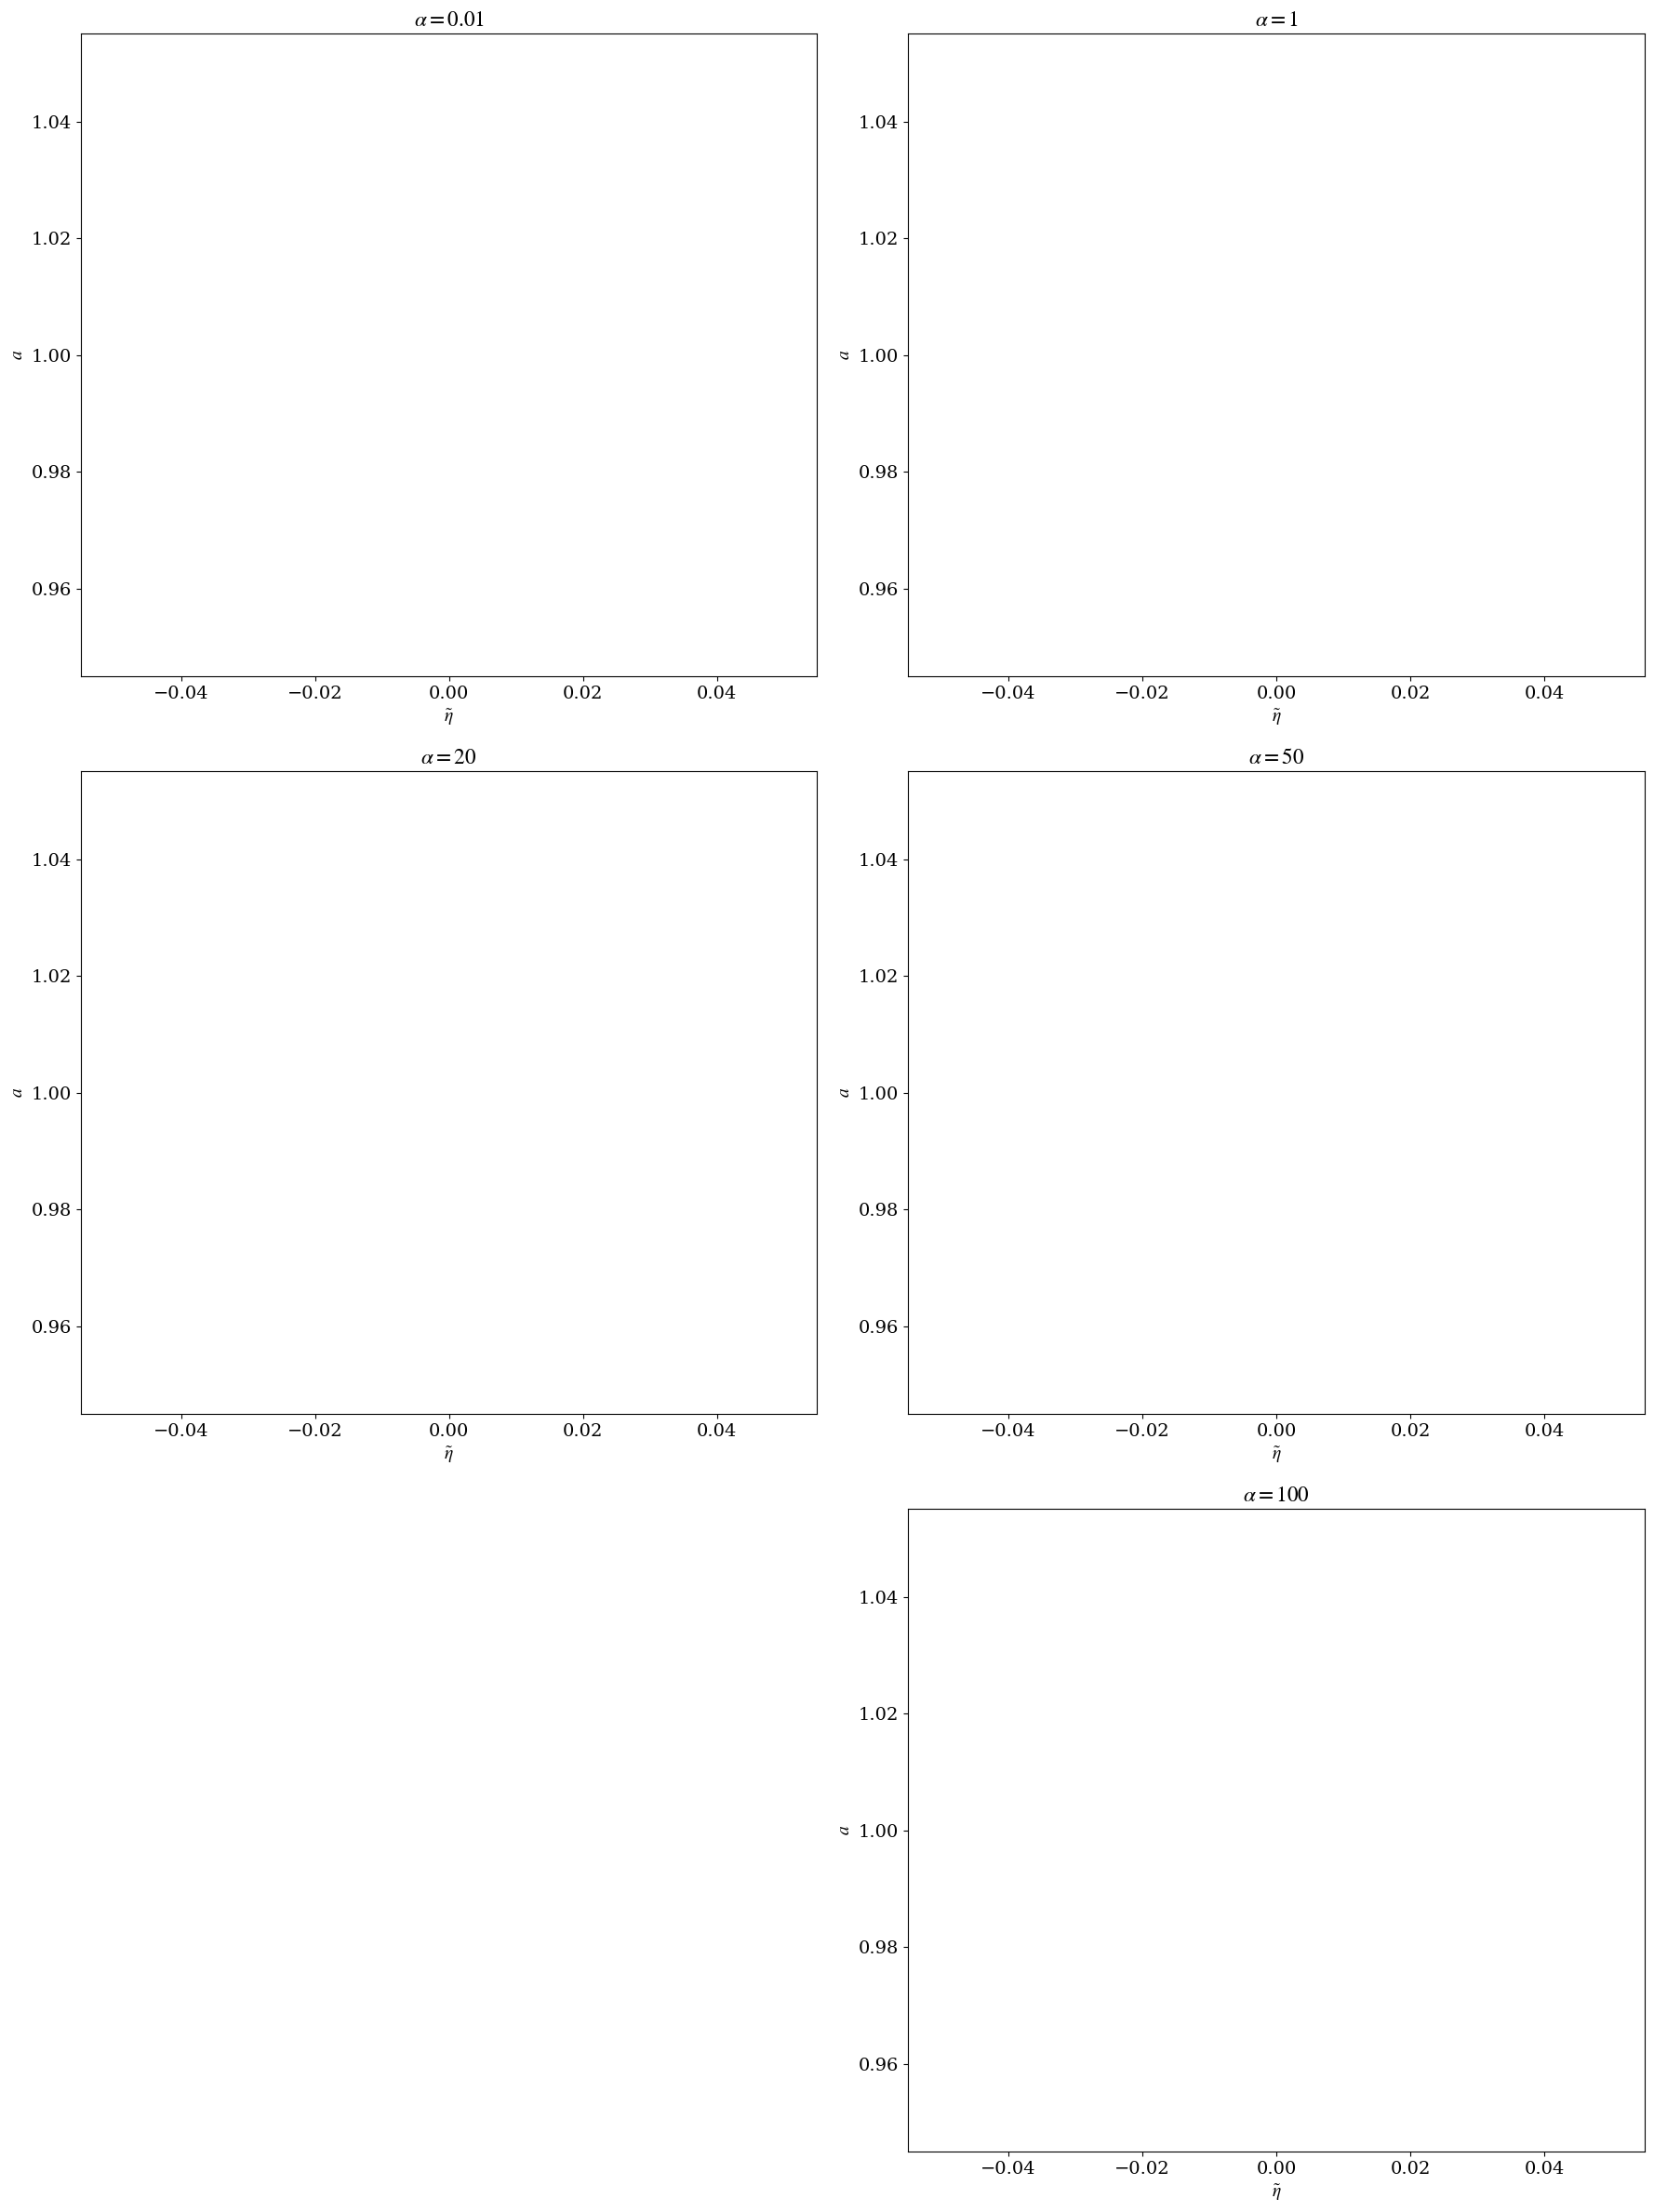

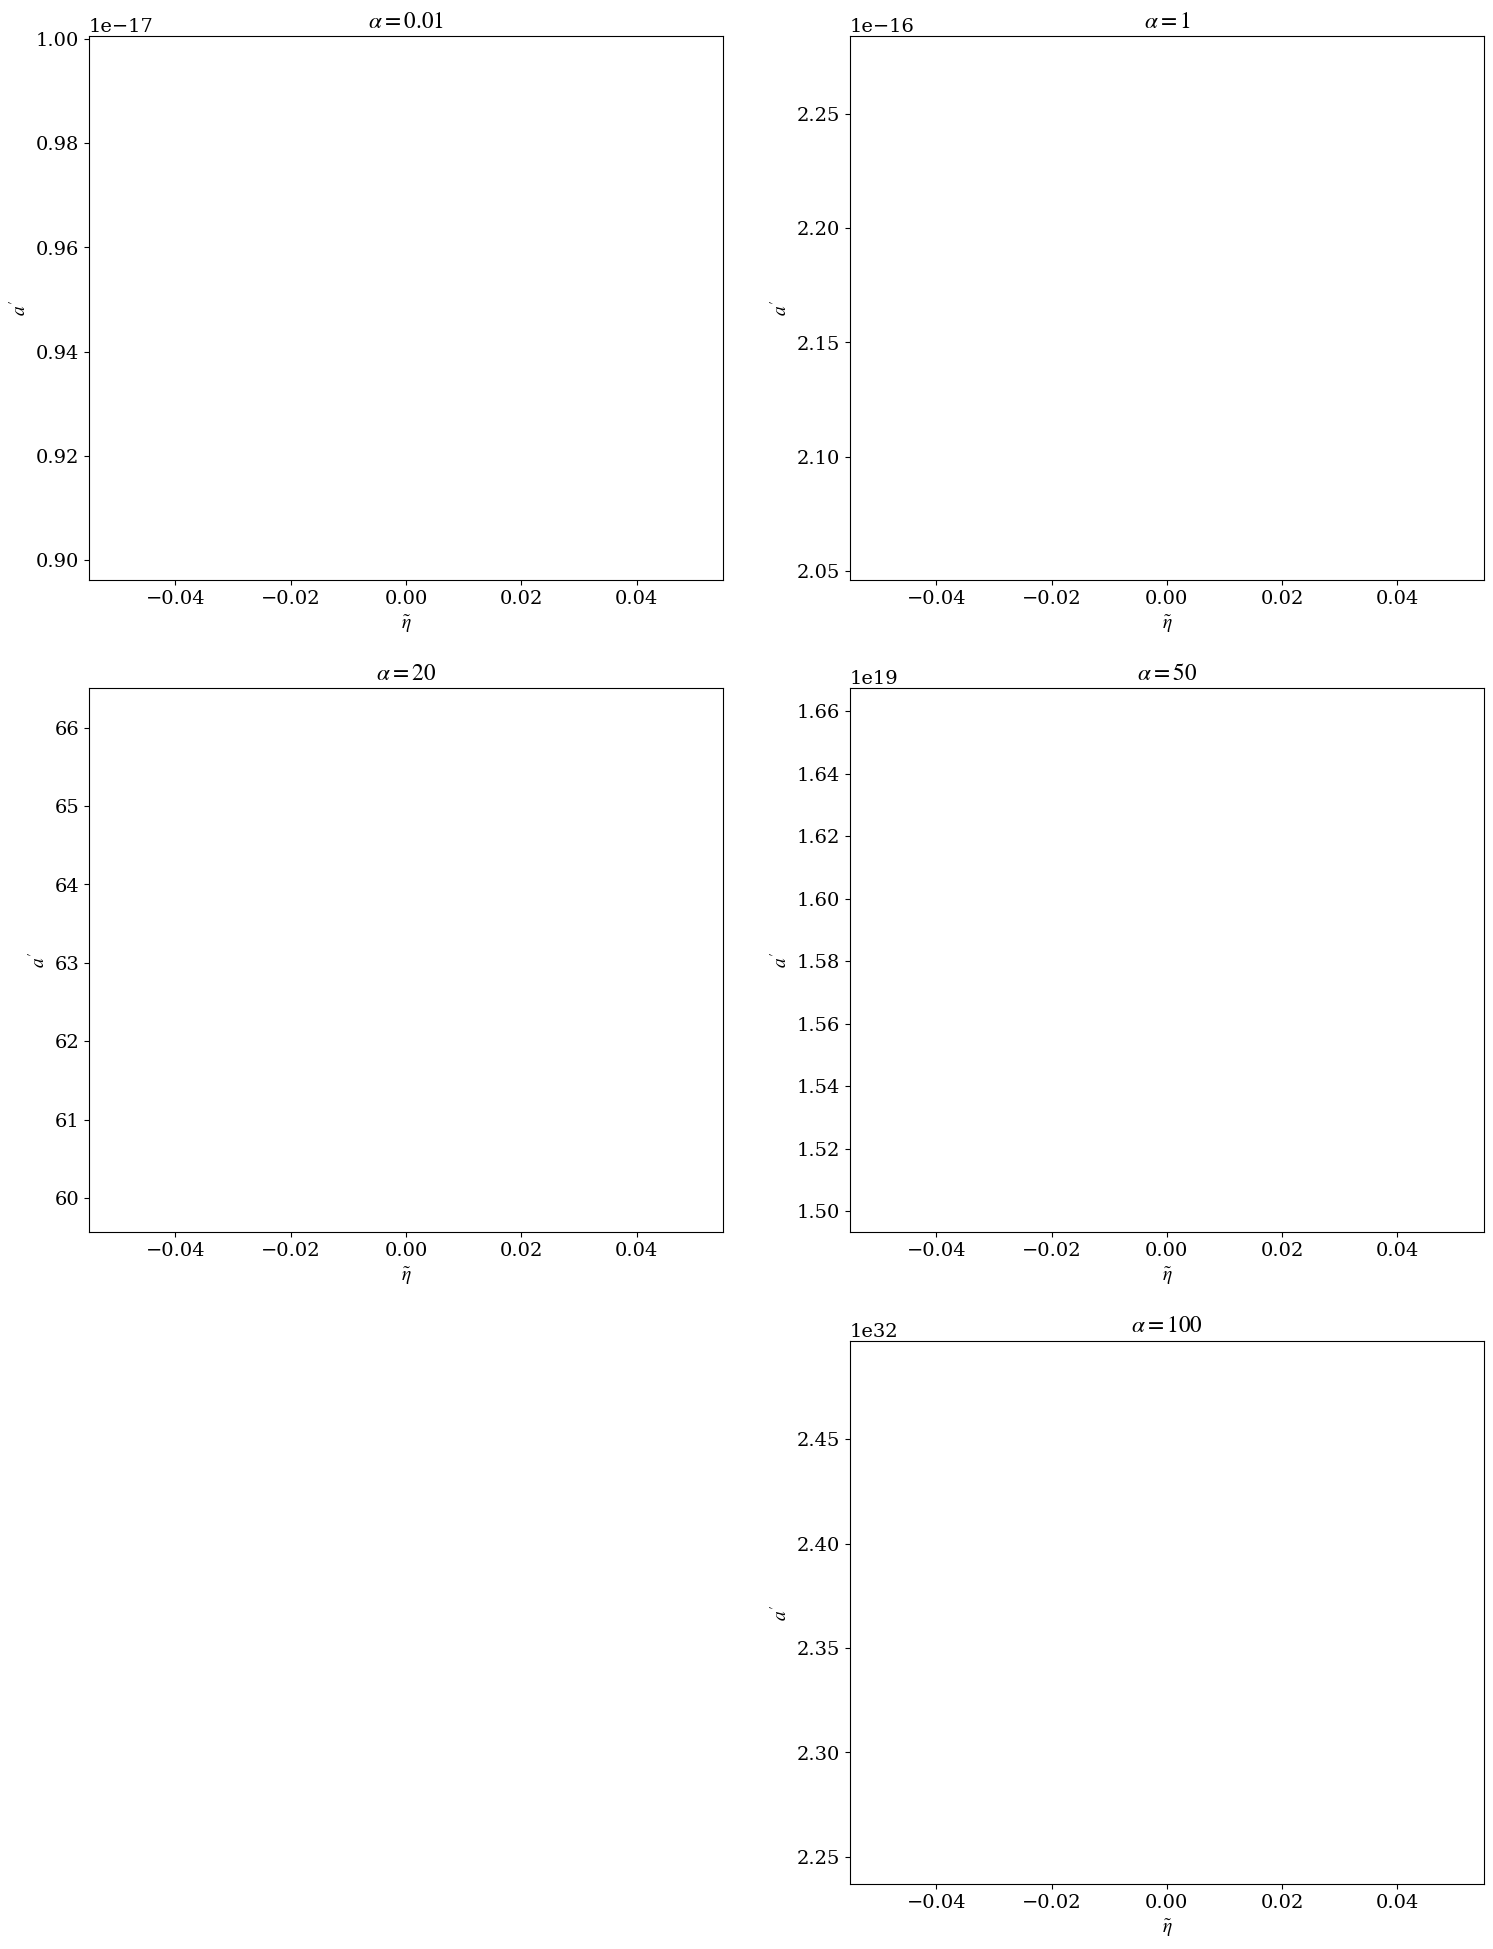

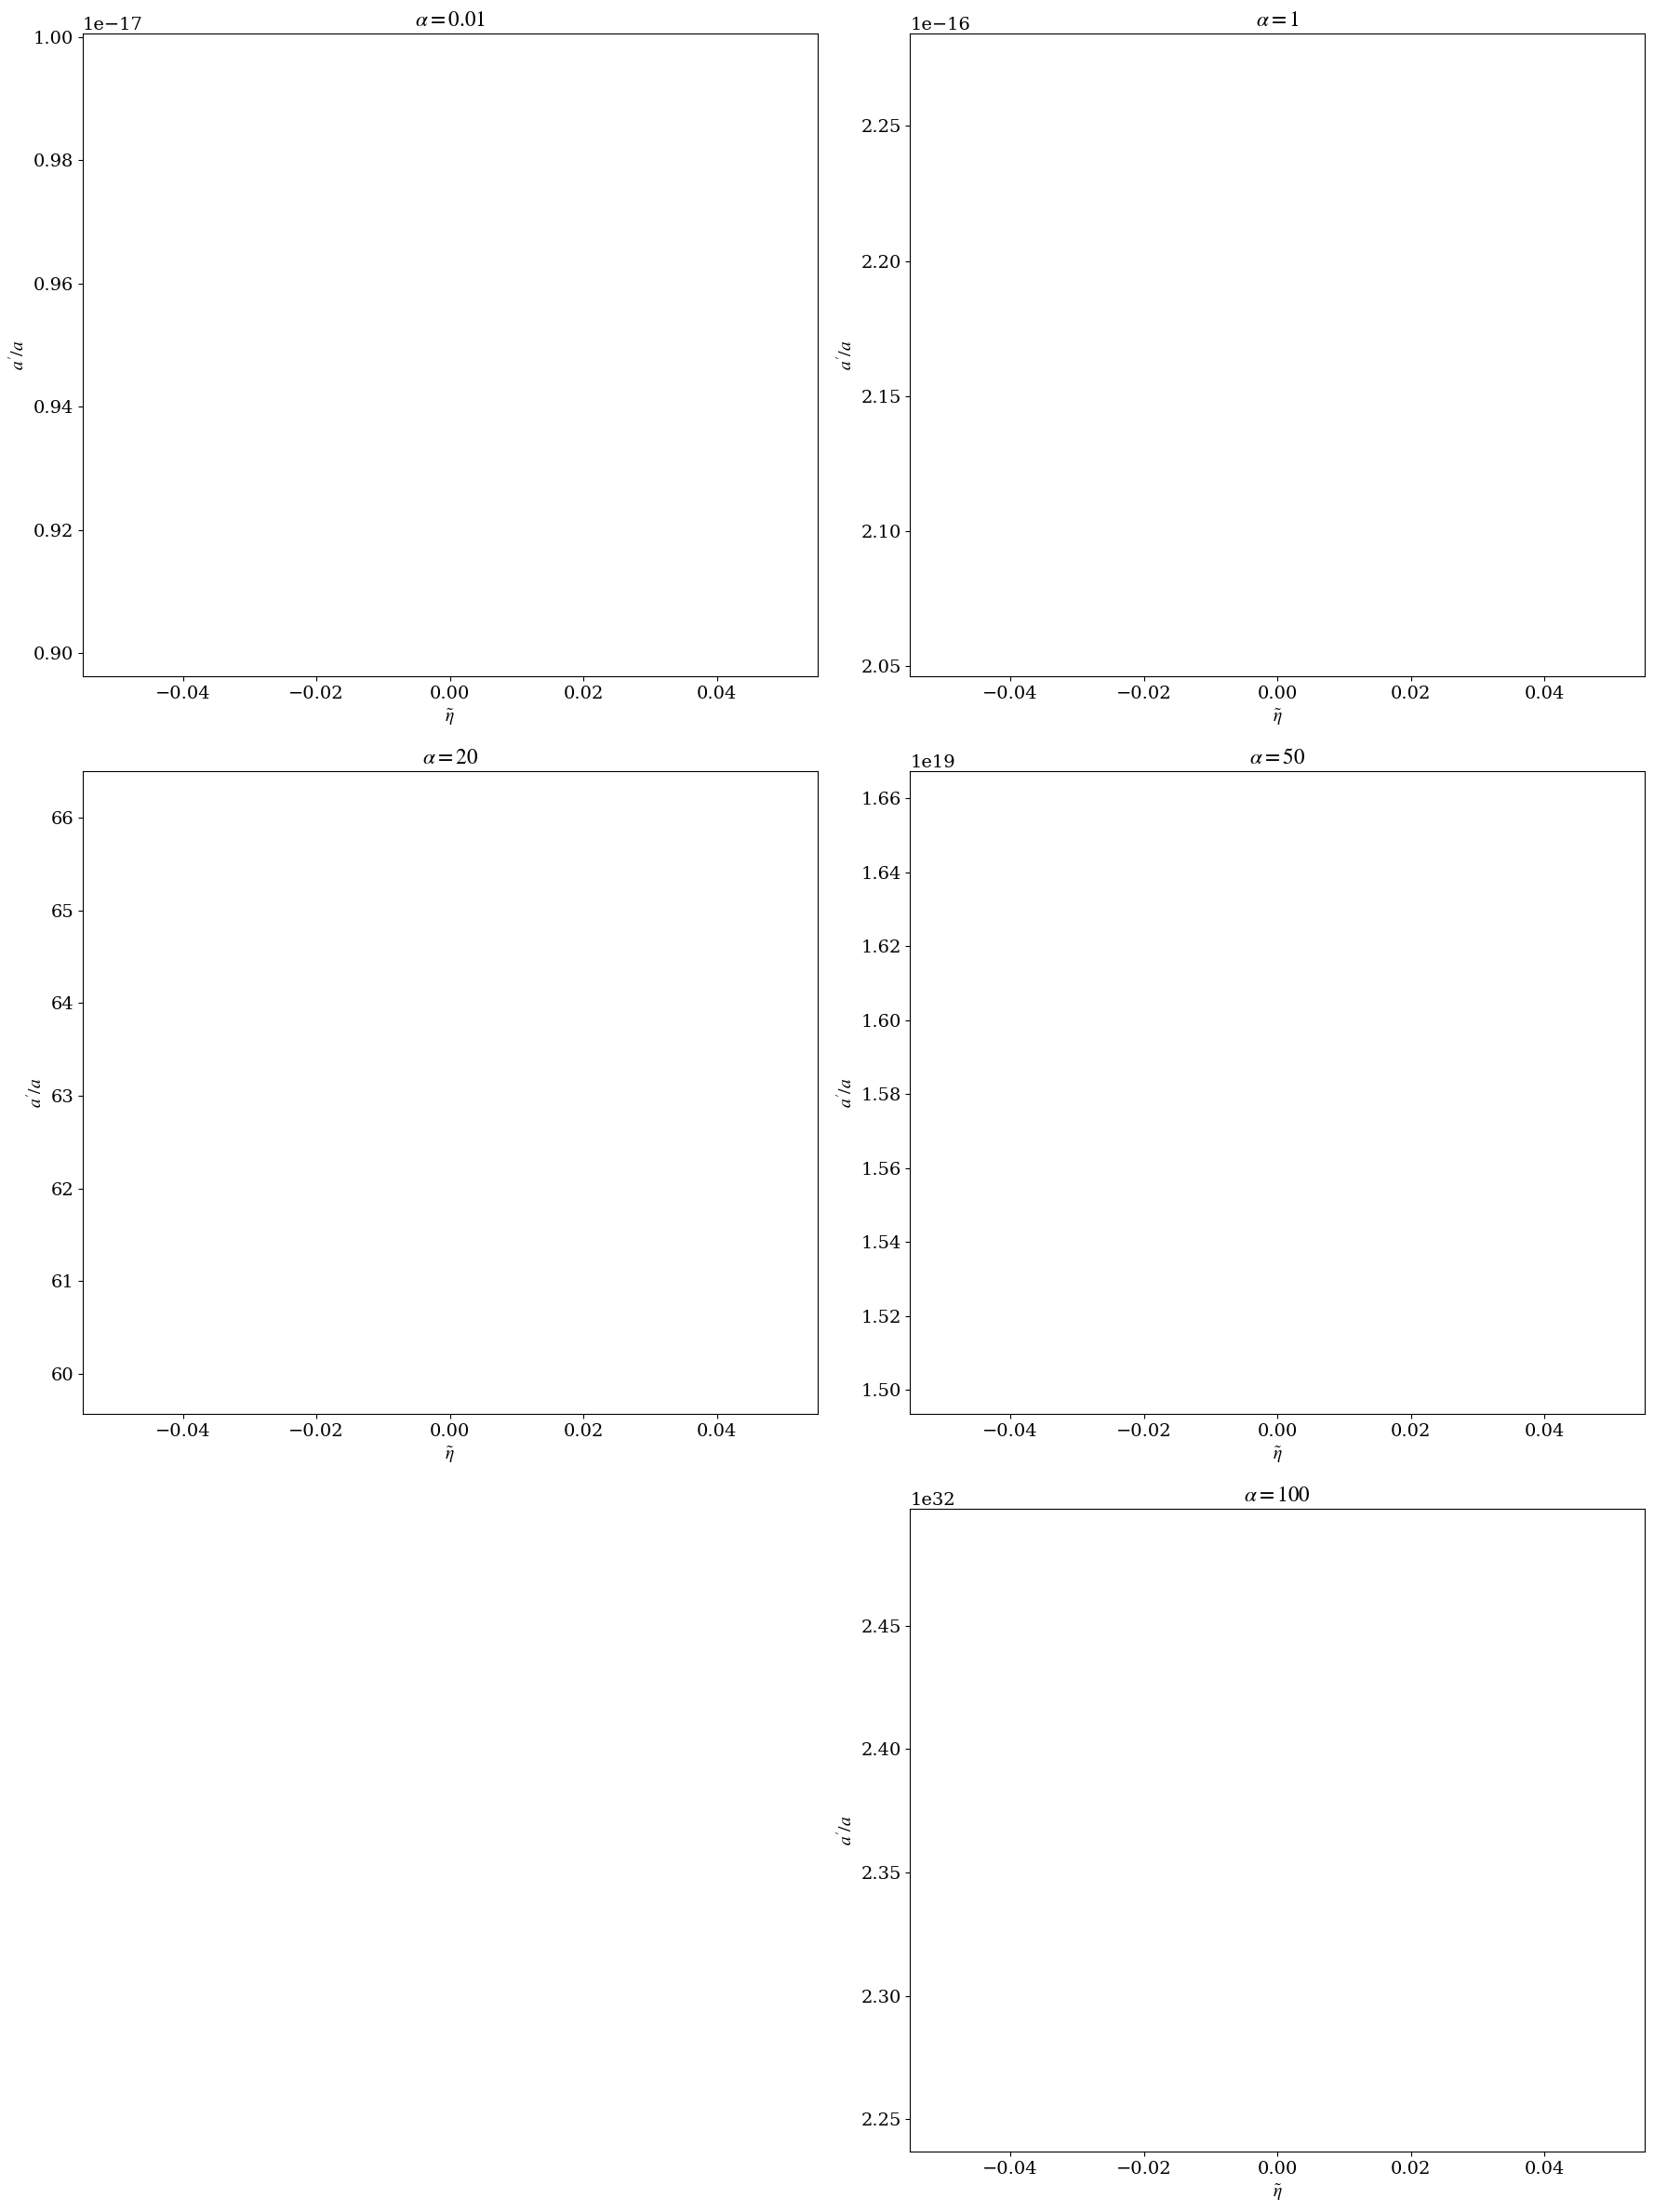

In [3]:
expansion = True

if expansion == True:
    # load the file in aDat
    aData001 = np.loadtxt(dira001 + "average_scale_factor.txt")
    aData1 = np.loadtxt(dira1 + "average_scale_factor.txt")
    aData20 = np.loadtxt(dira20 + "average_scale_factor.txt")
    aData50 = np.loadtxt(dira50 + "average_scale_factor.txt")
    aData100 = np.loadtxt(dira100 + "average_scale_factor.txt")
    
    #plot a
    plt.figure(figsize=(18, 24))
    
    plt.subplot(3, 2, 1)
    plt.plot(aData001[:,0], aData001[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\alpha = 0.01$')

    plt.subplot(3, 2, 2)
    plt.plot(aData1[:,0], aData1[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\alpha = 1$')

    plt.subplot(3, 2, 3)
    plt.plot(aData20[:,0], aData20[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\alpha = 20$')

    plt.subplot(3, 2, 4)
    plt.plot(aData50[:,0], aData50[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\alpha = 50$')

    plt.subplot(3, 2, 6)
    plt.plot(aData100[:,0], aData100[:,1])
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r'$\alpha = 100$')

    plt.tight_layout()
    plt.show()
    
    #plot a'
    plt.figure(figsize=(18, 24))
    
    plt.subplot(3, 2, 1)
    plt.plot(aData001[:,0], aData001[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 0.01$')

    plt.subplot(3, 2, 2)
    plt.plot(aData1[:,0], aData1[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 1$')

    plt.subplot(3, 2, 3)
    plt.plot(aData20[:,0], aData20[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 20$')

    plt.subplot(3, 2, 4)
    plt.plot(aData50[:,0], aData50[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 50$')

    plt.subplot(3, 2, 6)
    plt.plot(aData100[:,0], aData100[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 100$')
    
    #plot a'/a
    plt.figure(figsize=(18, 24))
    
    plt.subplot(3, 2, 1)
    plt.plot(aData001[:,0], aData001[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 0.01$')

    plt.subplot(3, 2, 2)
    plt.plot(aData1[:,0], aData1[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 1$')

    plt.subplot(3, 2, 3)
    plt.plot(aData20[:,0], aData20[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 20$')

    plt.subplot(3, 2, 4)
    plt.plot(aData50[:,0], aData50[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 50$')

    plt.subplot(3, 2, 6)
    plt.plot(aData100[:,0], aData100[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r'$\alpha = 100$')

    plt.tight_layout()
    plt.show()

else:
    aData001 = None
    aData1 = None
    aData20 = None
    aData50 = None
    aData100 = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [4]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")
    
    if aDat is not None:
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

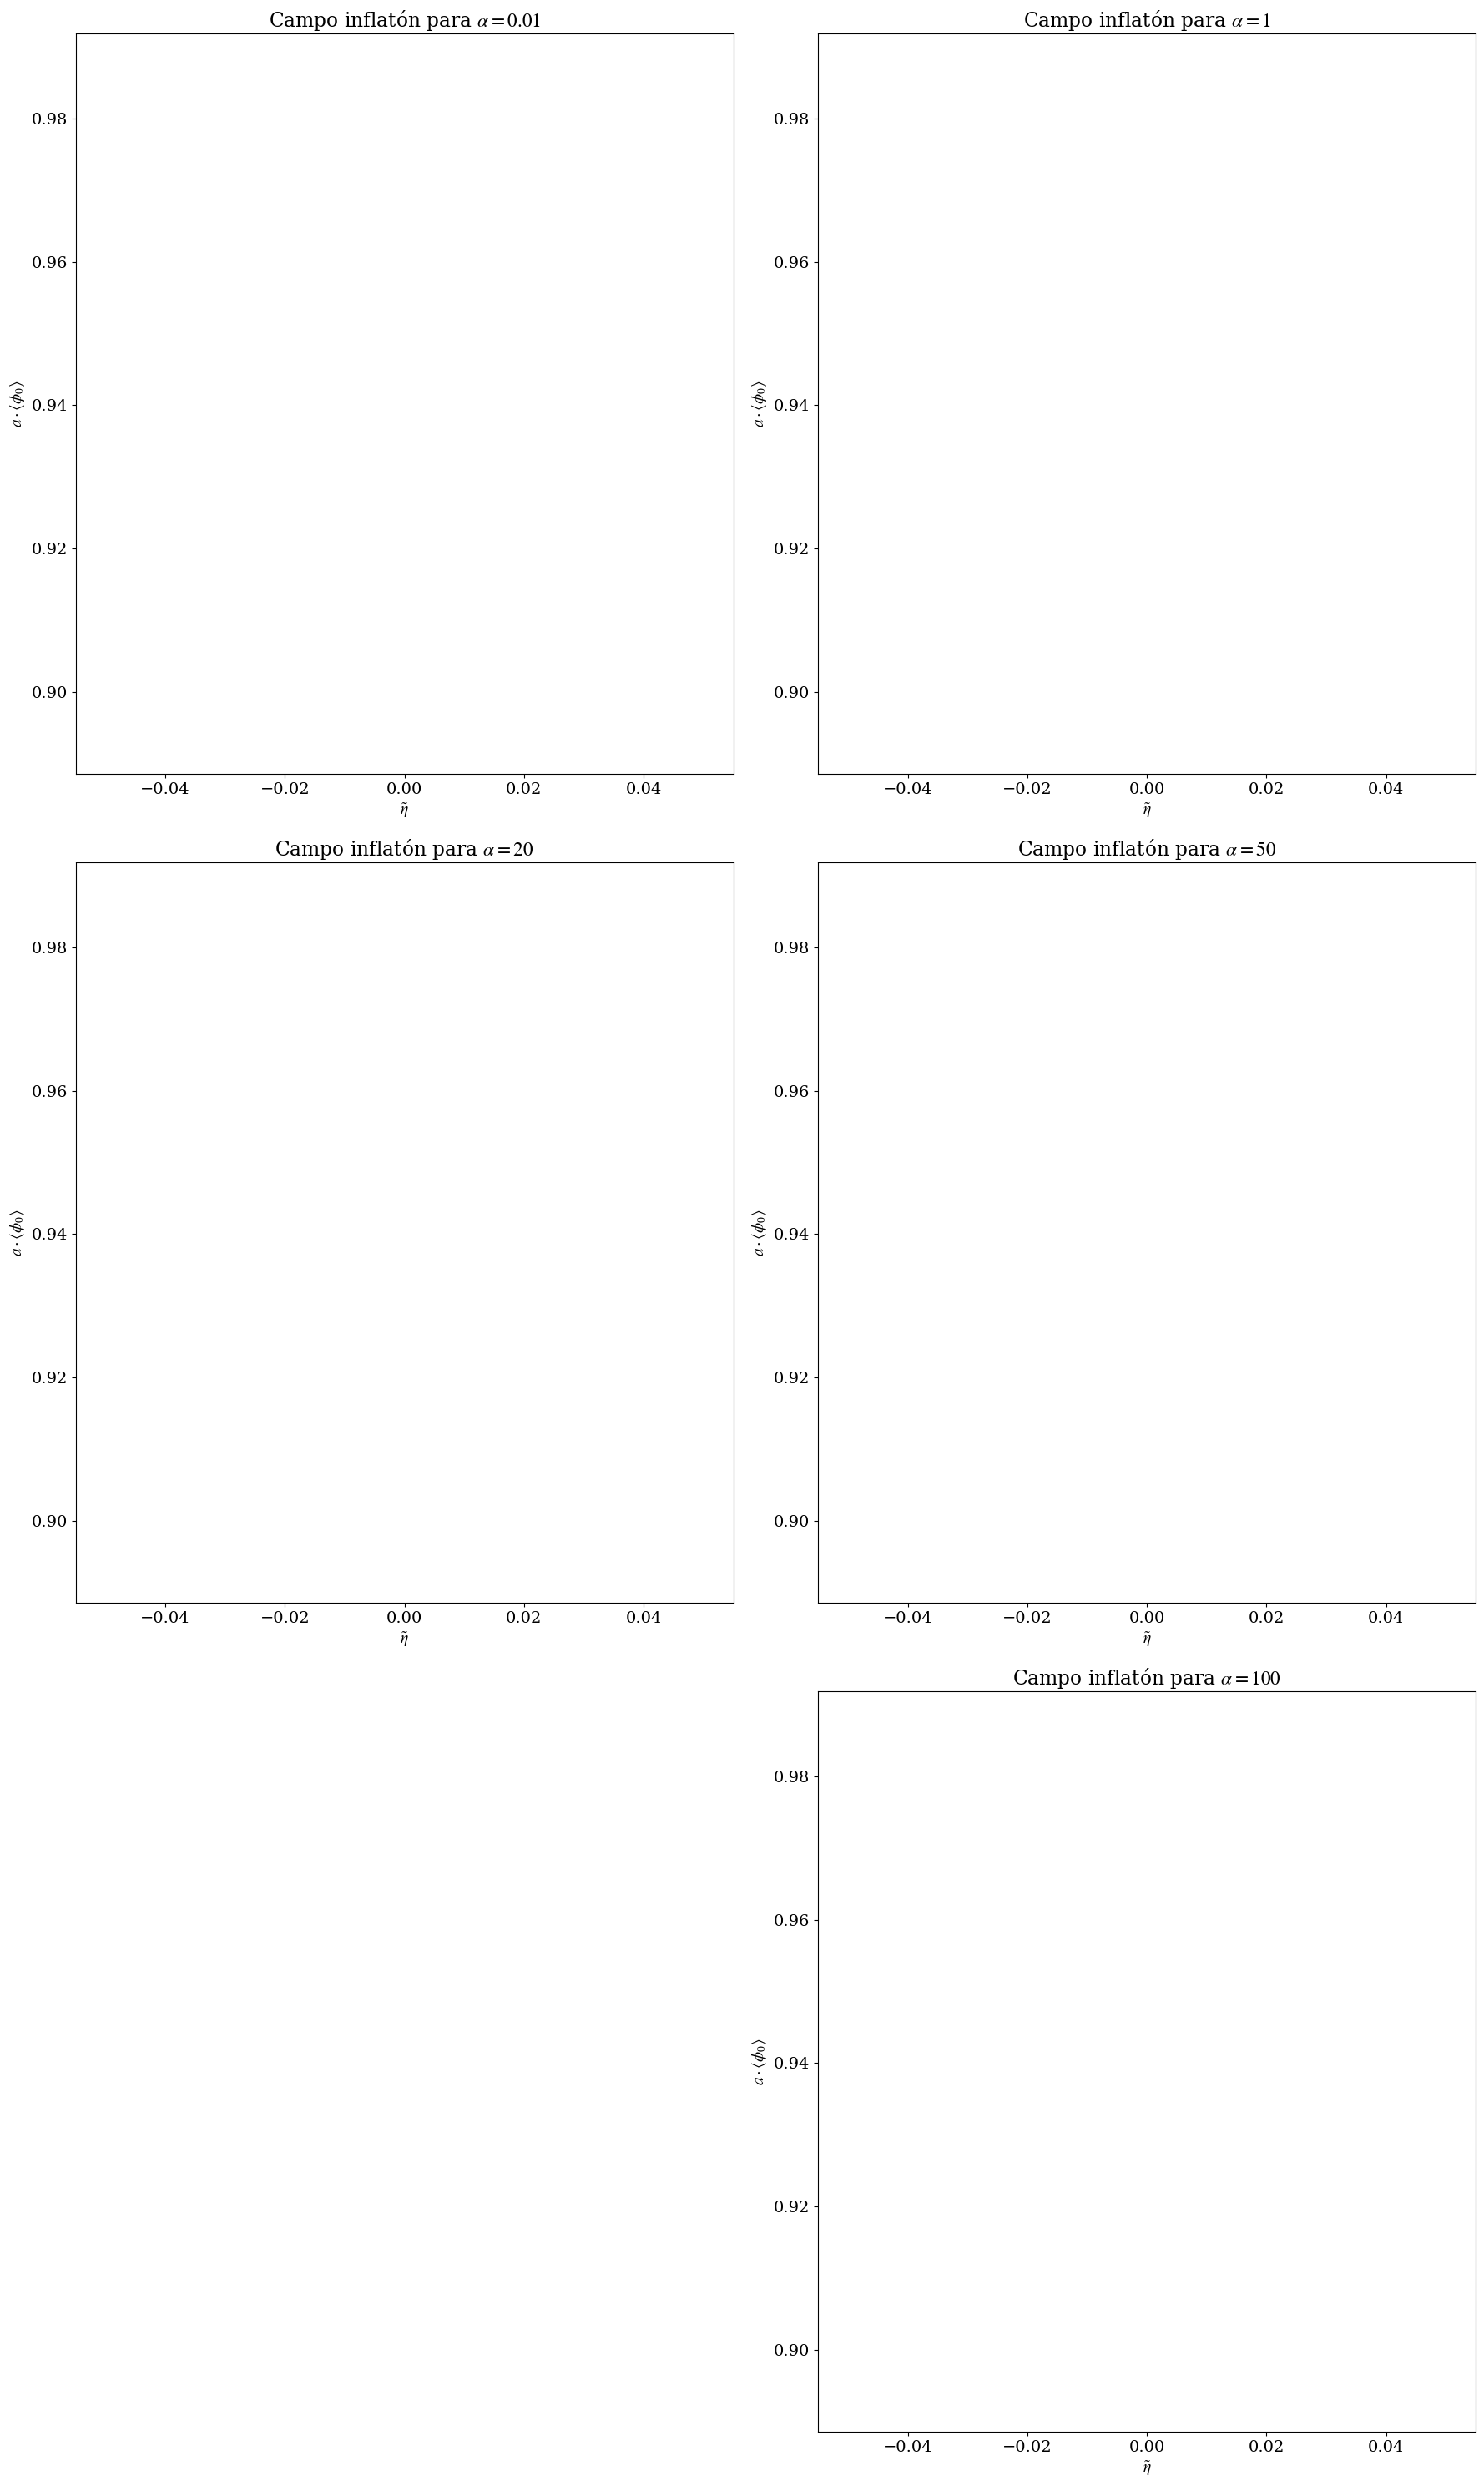

In [5]:
infData001 = np.loadtxt(dira001 + "average_scalar_0.txt")
infData1 = np.loadtxt(dira1 + "average_scalar_0.txt")
infData20 = np.loadtxt(dira20 + "average_scalar_0.txt")
infData50 = np.loadtxt(dira50 + "average_scalar_0.txt")
infData100 = np.loadtxt(dira100 + "average_scalar_0.txt")

plt.figure(figsize=(18, 30))

plt.subplot(3, 2, 1)
plot_fld(infData001,"0",aData1)
plt.title(r'Campo inflatón para $\alpha = 0.01$')

plt.subplot(3, 2, 2)
plot_fld(infData1,"0",aData1)
plt.title(r'Campo inflatón para $\alpha = 1$')

plt.subplot(3, 2, 3)
plot_fld(infData20,"0",aData20)
plt.title(r'Campo inflatón para $\alpha = 20$')

plt.subplot(3, 2, 4)
plot_fld(infData50,"0",aData50)
plt.title(r'Campo inflatón para $\alpha = 50$')

plt.subplot(3, 2, 6)
plot_fld(infData100,"0",aData100)
plt.title(r'Campo inflatón para $\alpha = 100$')

plt.tight_layout()
plt.show()

## Field $1$ (daughter field)

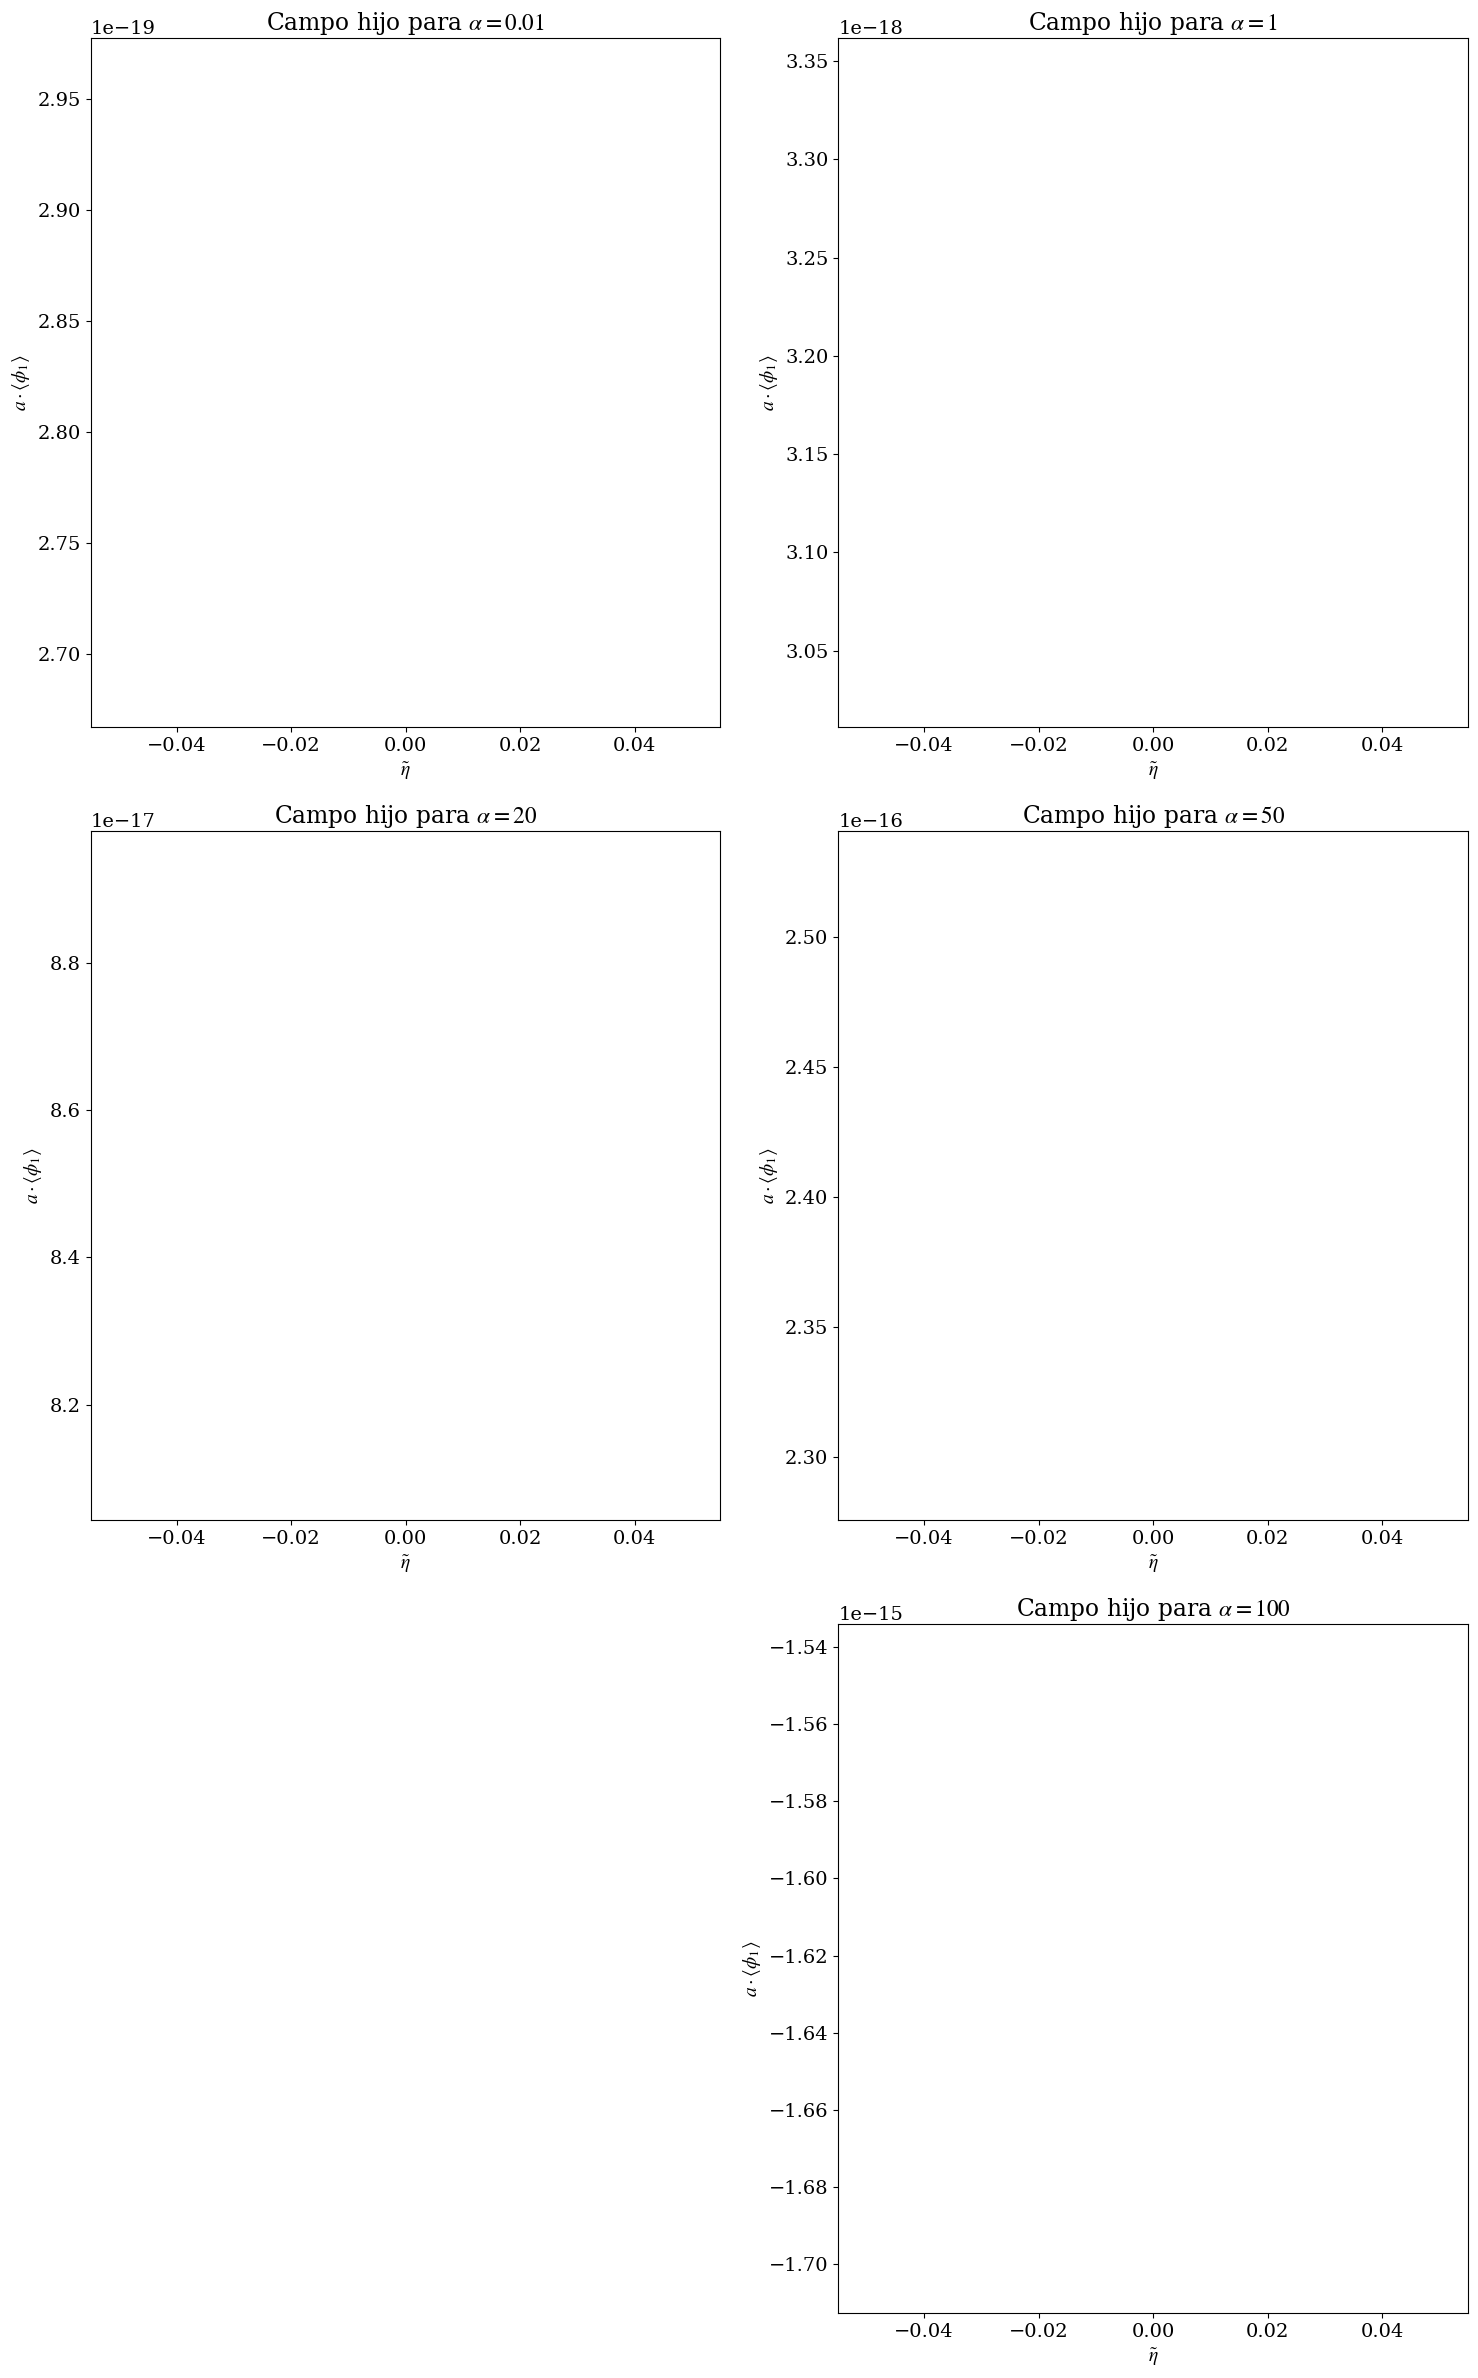

In [6]:
infData001 = np.loadtxt(dira001 + "average_scalar_1.txt")
infData1 = np.loadtxt(dira1 + "average_scalar_1.txt")
infData20 = np.loadtxt(dira20 + "average_scalar_1.txt")
infData50 = np.loadtxt(dira50 + "average_scalar_1.txt")
infData100 = np.loadtxt(dira100 + "average_scalar_1.txt")

plt.figure(figsize=(15, 24))

plt.subplot(3, 2, 1)
plot_fld(infData001,"1",aData001)
plt.title(r'Campo hijo para $\alpha = 0.01$')

plt.subplot(3, 2, 2)
plot_fld(infData1,"1",aData1)
plt.title(r'Campo hijo para $\alpha = 1$')

plt.subplot(3, 2, 3)
plot_fld(infData20,"1",aData20)
plt.title(r'Campo hijo para $\alpha = 20$')

plt.subplot(3, 2, 4)
plot_fld(infData50,"1",aData50)
plt.title(r'Campo hijo para $\alpha = 50$')

plt.subplot(3, 2, 6)
plot_fld(infData100,"1",aData100)
plt.title(r'Campo hijo para $\alpha = 100$')

plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

/tmp/ipykernel_79529/2322680986.py:11: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')
/tmp/ipykernel_79529/2322680986.py:17: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')
/tmp/ipykernel_79529/2322680986.py:23: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')
/tmp/ipykernel_79529/2322680986.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


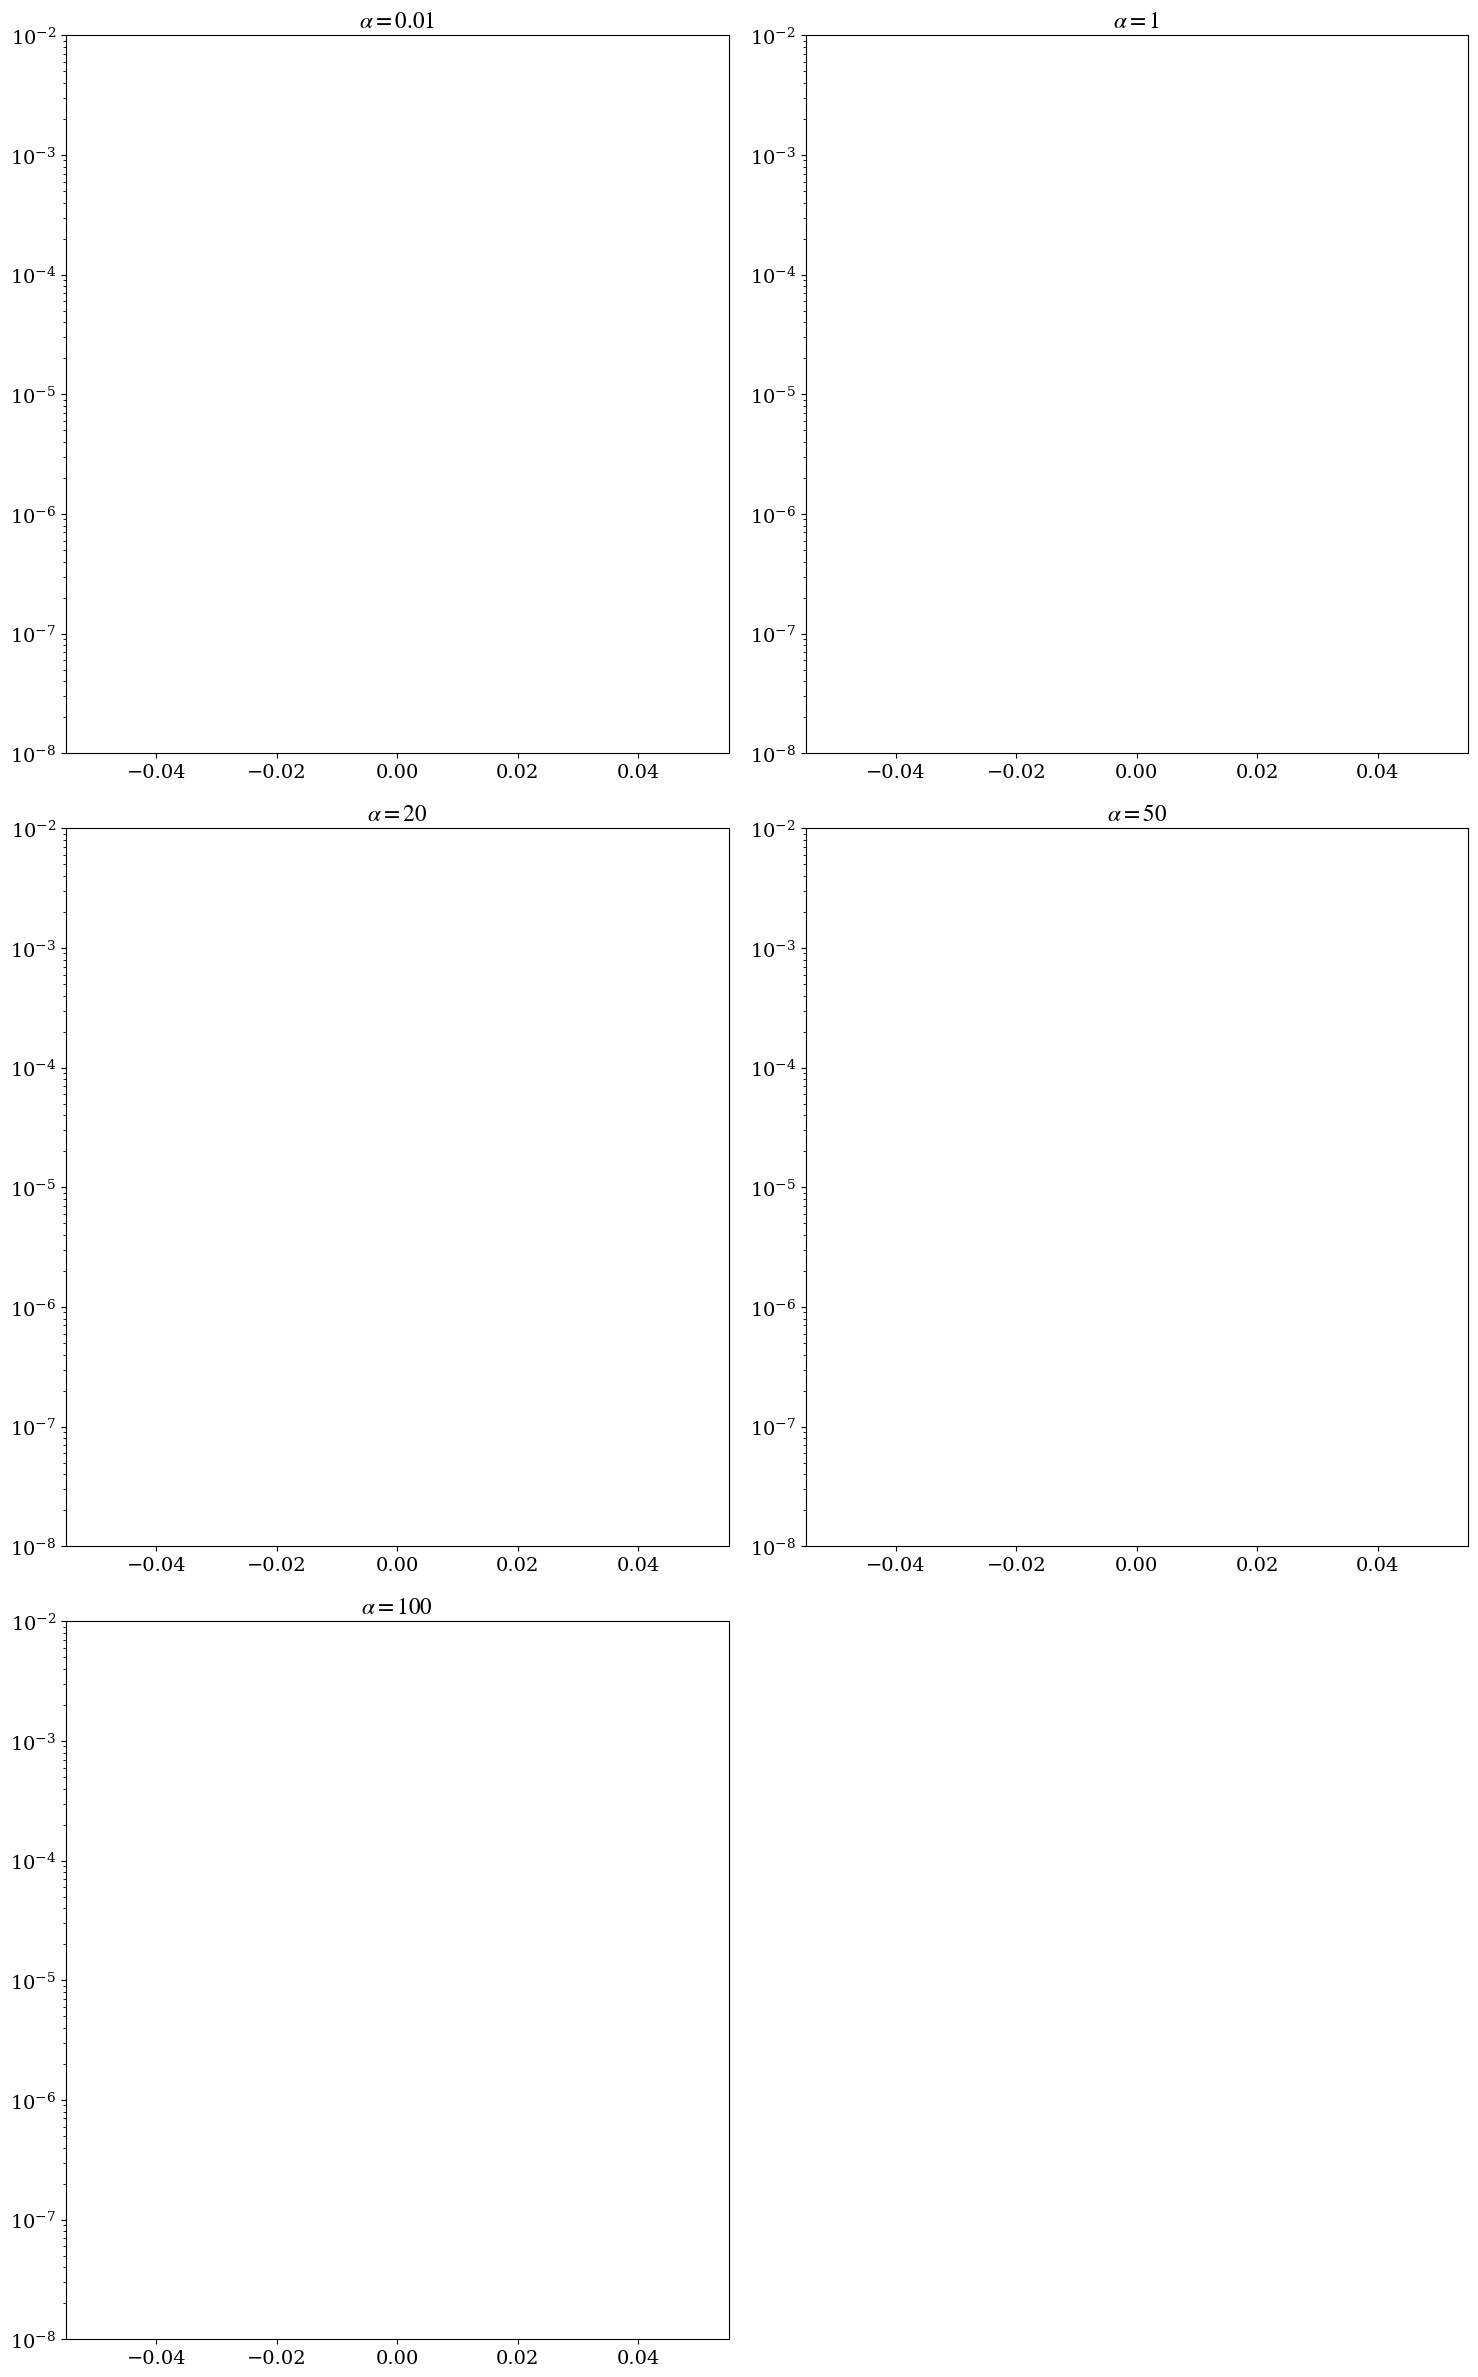

In [7]:
enConsData001 = np.loadtxt(dira001 + "average_energy_conservation.txt")
enConsData1 = np.loadtxt(dira1 + "average_energy_conservation.txt")
enConsData20 = np.loadtxt(dira20 + "average_energy_conservation.txt")
enConsData50 = np.loadtxt(dira50 + "average_energy_conservation.txt")
enConsData100 = np.loadtxt(dira100 + "average_energy_conservation.txt")

plt.figure(figsize=(15, 24))

plt.subplot(3, 2, 1)
plt.plot(enConsData001[:,0], enConsData001[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\alpha = 0.01$')

plt.subplot(3, 2, 2)
plt.plot(enConsData1[:,0], enConsData1[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\alpha = 1$')

plt.subplot(3, 2, 3)
plt.plot(enConsData20[:,0], enConsData20[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\alpha = 20$')

plt.subplot(3, 2, 4)
plt.plot(enConsData50[:,0], enConsData50[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\alpha = 50$')

plt.subplot(3, 2, 5)
plt.plot(enConsData100[:,0], enConsData100[:,1])
plt.yscale('log')
plt.ylim([1e-8,0.01])
plt.title(r'$\alpha = 100$')

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

/tmp/ipykernel_79529/3948670275.py:24: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xscale('log')
/tmp/ipykernel_79529/3948670275.py:33: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xscale('log')
/tmp/ipykernel_79529/3948670275.py:42: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xscale('log')
/tmp/ipykernel_79529/3948670275.py:51: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xscale('log')
/tmp/ipykernel_79529/3948670275.py:60: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xscale('log')


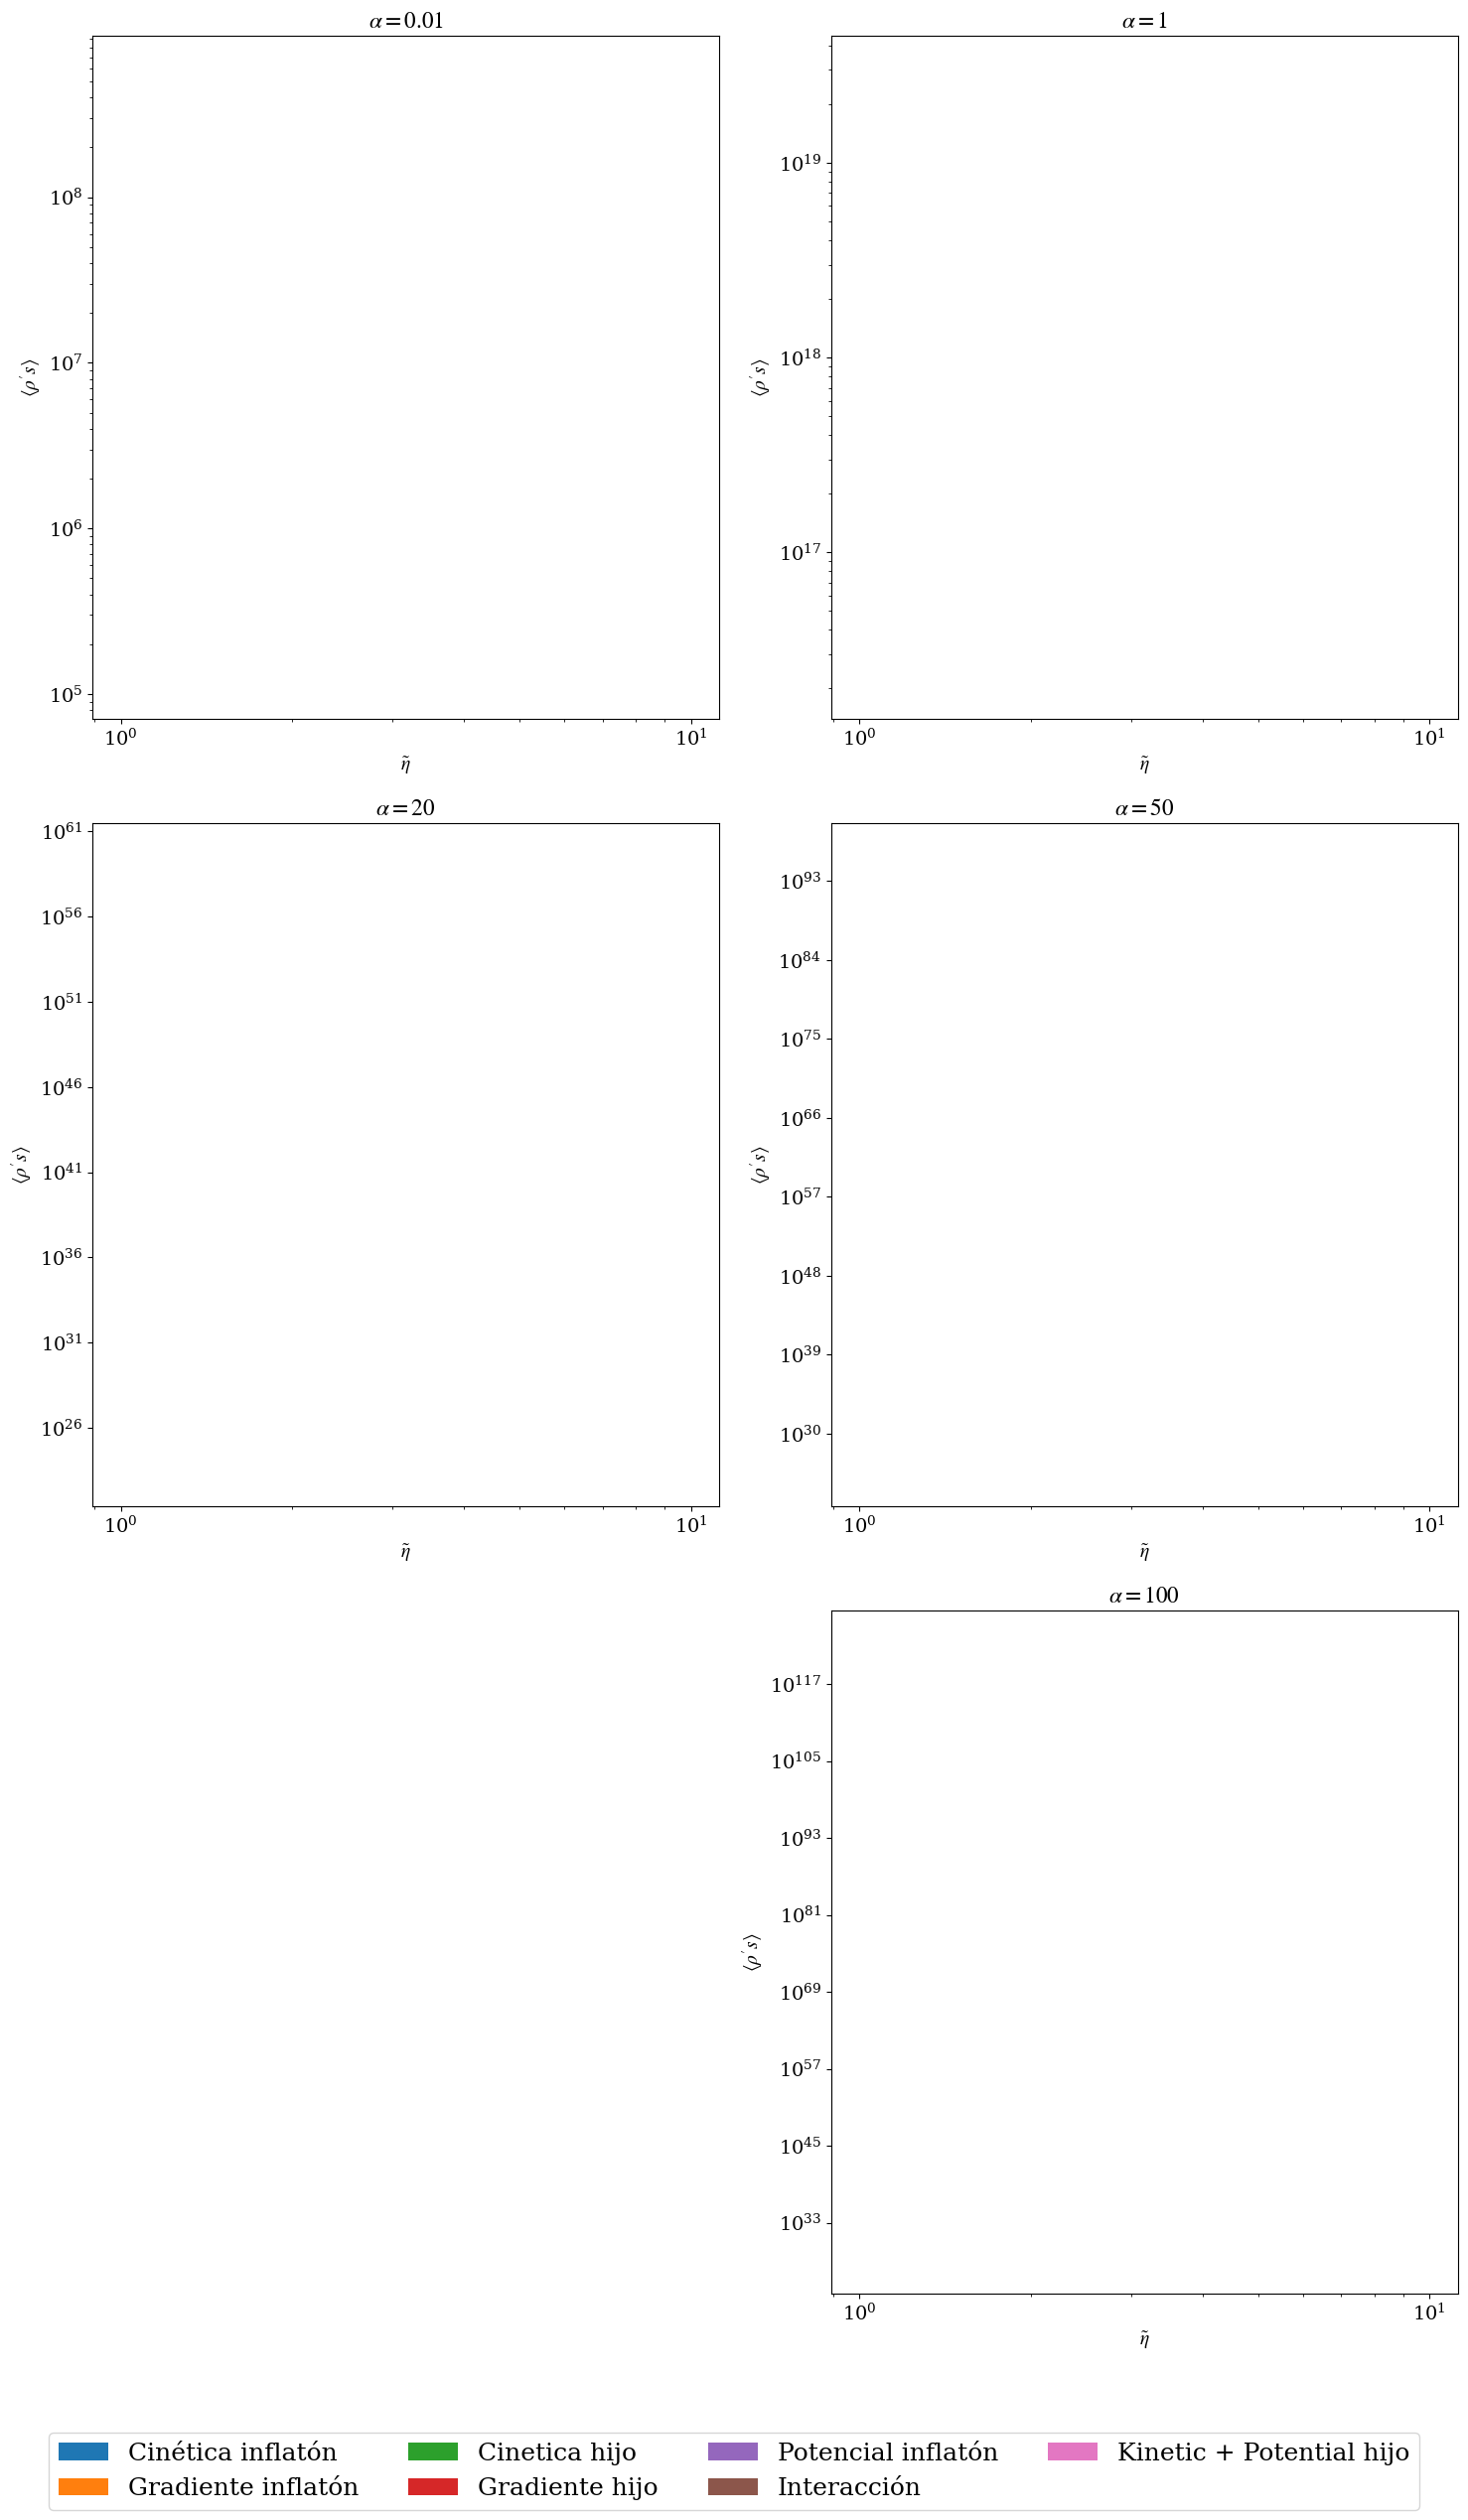

In [8]:
enData001 = np.loadtxt(dira001 + "average_energies.txt")
enData1 = np.loadtxt(dira1 + "average_energies.txt")
enData20 = np.loadtxt(dira20 + "average_energies.txt")
enData50 = np.loadtxt(dira50 + "average_energies.txt")
enData100 = np.loadtxt(dira100 + "average_energies.txt")

nColumns001 = np.shape(enData001)[1]
nColumns1 = np.shape(enData1)[1]
nColumns20 = np.shape(enData20)[1]
nColumns50 = np.shape(enData50)[1]
nColumns100 = np.shape(enData100)[1]

# set explicitly different colors, so we know who is who
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]
label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]

fig = plt.figure(figsize=(15, 24))

plt.subplot(3, 2, 1)
for i in range(1,nColumns001):
    plt.plot(enData001[:,0], enData001[:,1]**4 * enData001[:,i], color = colors[i-1])
plt.title(r'$\alpha = 0.01$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(3, 2, 2)
for i in range(1,nColumns1):
    plt.plot(enData1[:,0], enData1[:,1]**4 * enData1[:,i], color = colors[i-1])
plt.title(r'$\alpha = 1$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(3, 2, 3)
for i in range(1,nColumns20):
    plt.plot(enData20[:,0], enData20[:,1]**4 * enData20[:,i], color = colors[i-1])
plt.title(r'$\alpha = 20$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(3, 2, 4)
for i in range(1,nColumns50):
    plt.plot(enData50[:,0], enData50[:,1]**4 * enData50[:,i], color = colors[i-1])
plt.title(r'$\alpha = 50$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.subplot(3, 2, 6)
for i in range(1,nColumns100):
    plt.plot(enData100[:,0], enData100[:,1]**4 * enData100[:,i], color = colors[i-1])
plt.title(r'$\alpha = 100$')
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)


plt.tight_layout()
plt.show()
    

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [9]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=nSpectra-1)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

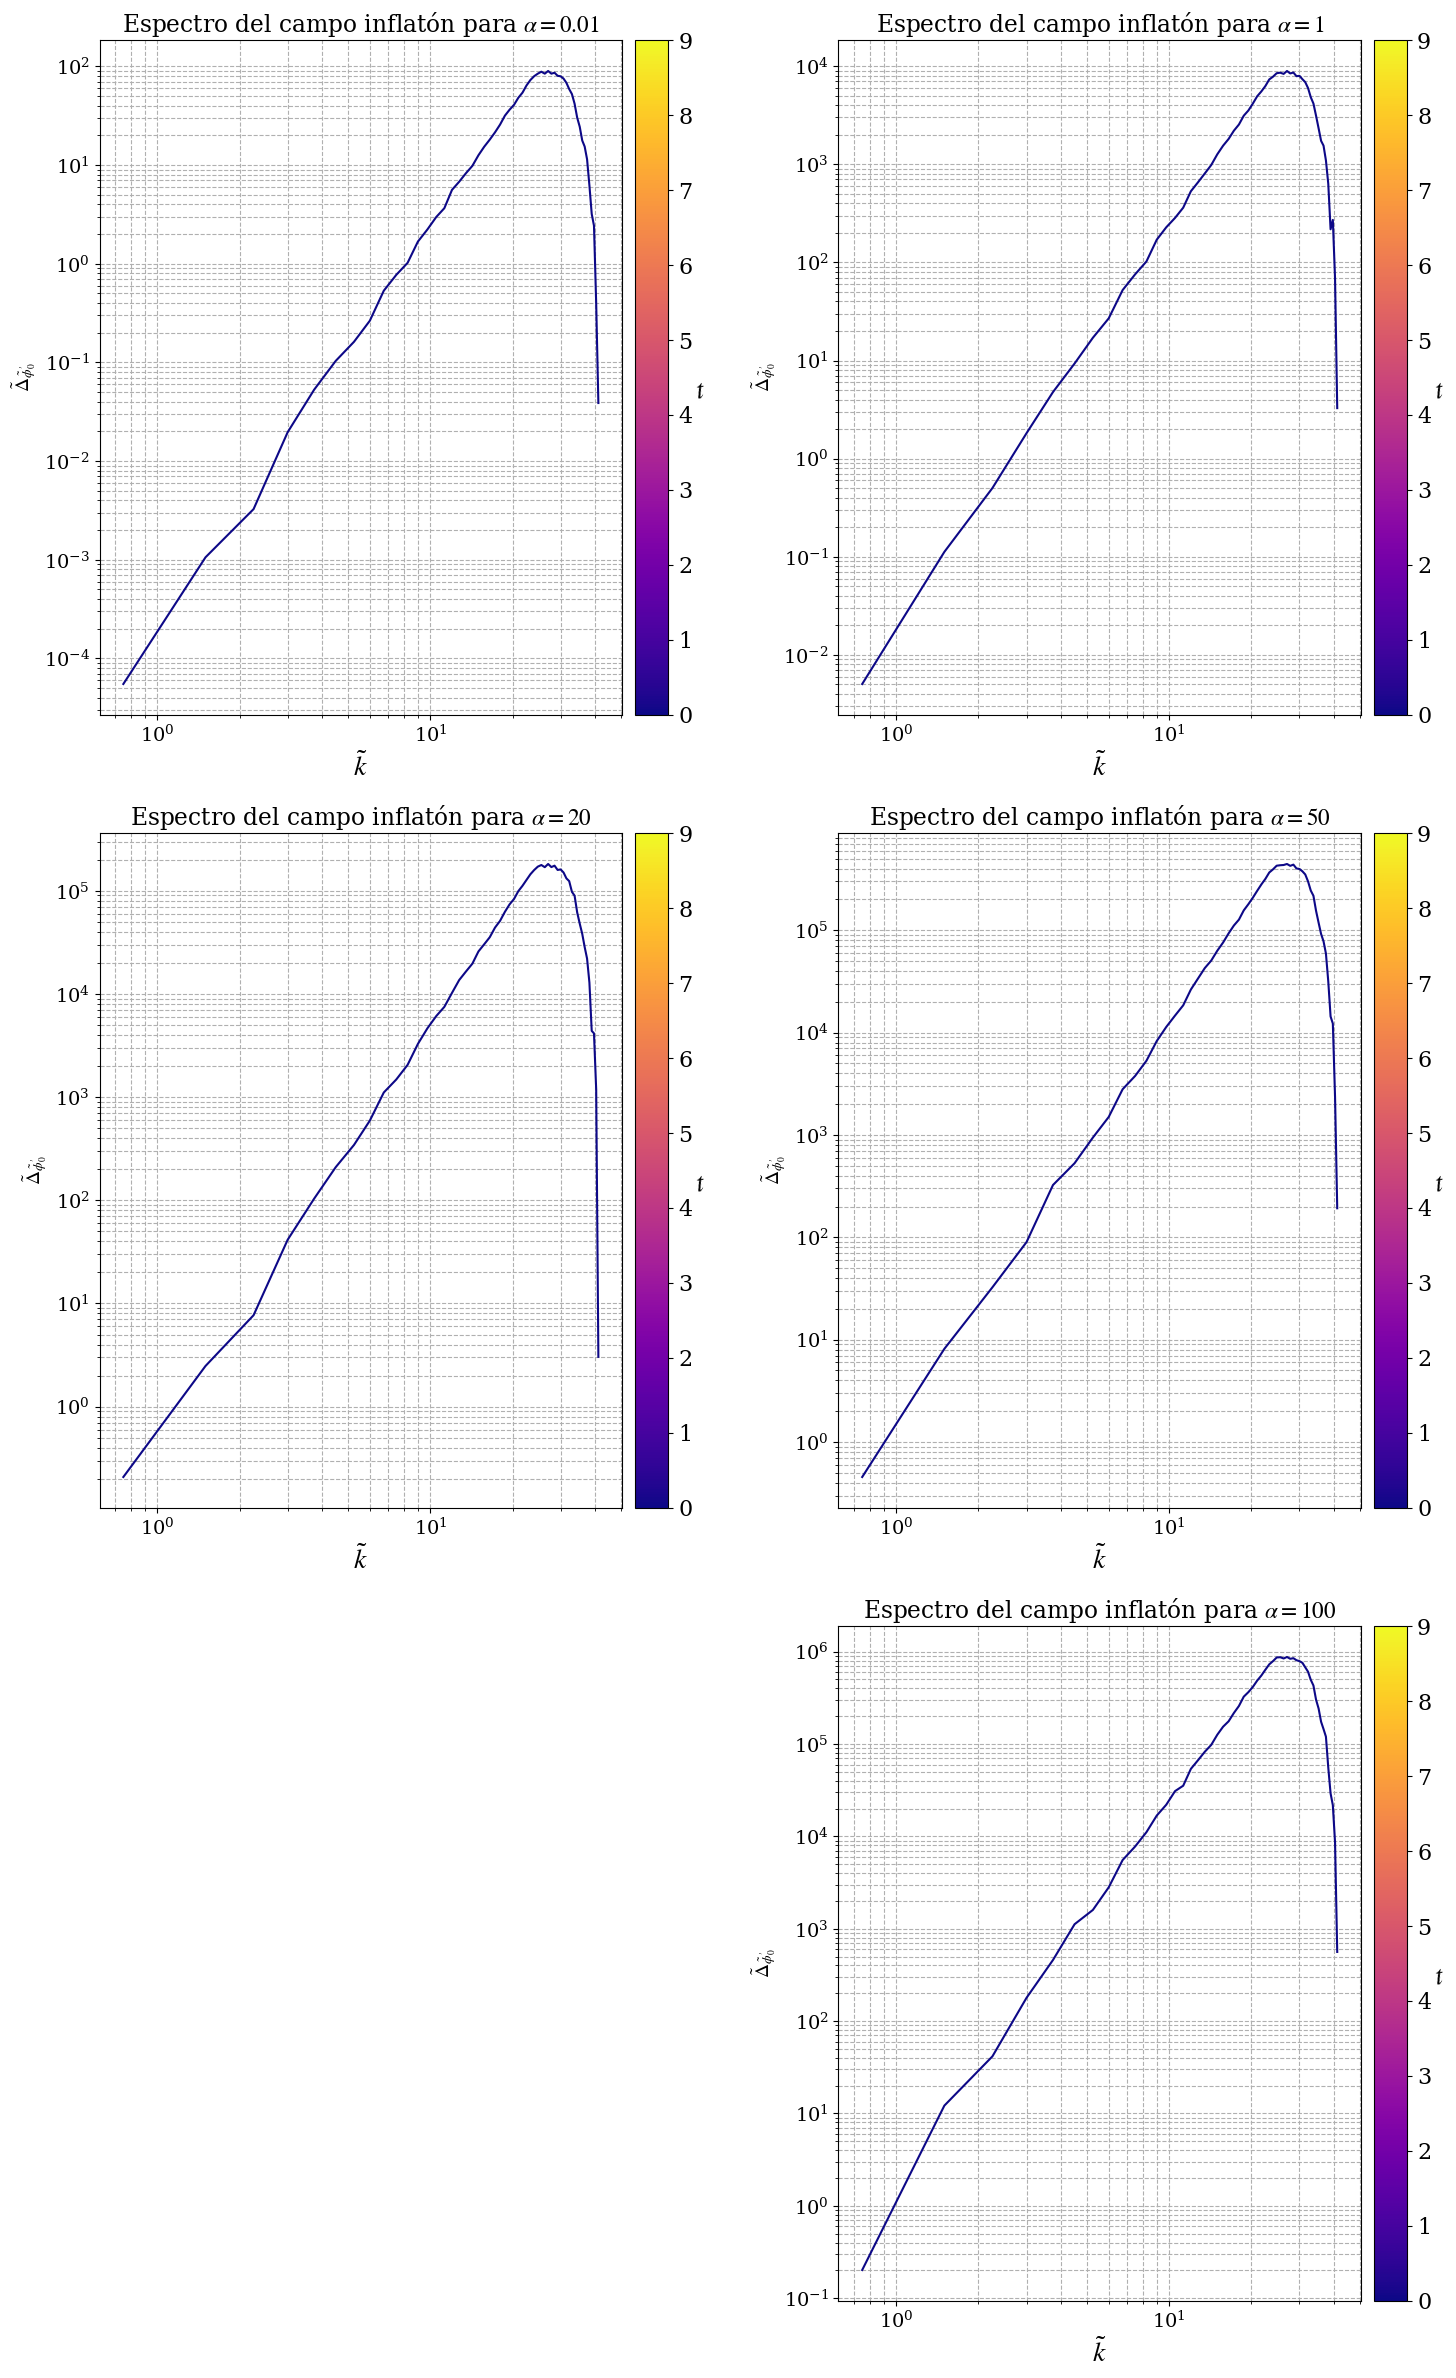

In [10]:
infSpa001, nBinsa001, nSpectraa001 = load_spectrum(dira001 + "spectra_scalar_0.txt")
infSpa1, nBinsa1, nSpectraa1 = load_spectrum(dira1 + "spectra_scalar_0.txt")
infSpa20, nBinsa20, nSpectraa20 = load_spectrum(dira20 + "spectra_scalar_0.txt")
infSpa50, nBinsa50, nSpectraa50 = load_spectrum(dira50 + "spectra_scalar_0.txt")
infSpa100, nBinsa100, nSpectraa100 = load_spectrum(dira100 + "spectra_scalar_0.txt")

plt.figure(figsize=(15, 24))

plt.subplot(3, 2, 1)
plot_spectrum(infSpa001, 2,  nBinsa001, nSpectraa001)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\alpha = 0.01$')

plt.subplot(3, 2, 2)
plot_spectrum(infSpa1, 2,  nBinsa1, nSpectraa1)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\alpha = 1$')

plt.subplot(3, 2, 3)
plot_spectrum(infSpa20, 2,  nBinsa20, nSpectraa20)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\alpha = 20$')

plt.subplot(3, 2, 4)
plot_spectrum(infSpa50, 2,  nBinsa50, nSpectraa50)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\alpha = 50$')

plt.subplot(3, 2, 6)
plot_spectrum(infSpa100, 2,  nBinsa100, nSpectraa100)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón para $\alpha = 100$')

plt.tight_layout()
plt.show()

## Daughter field

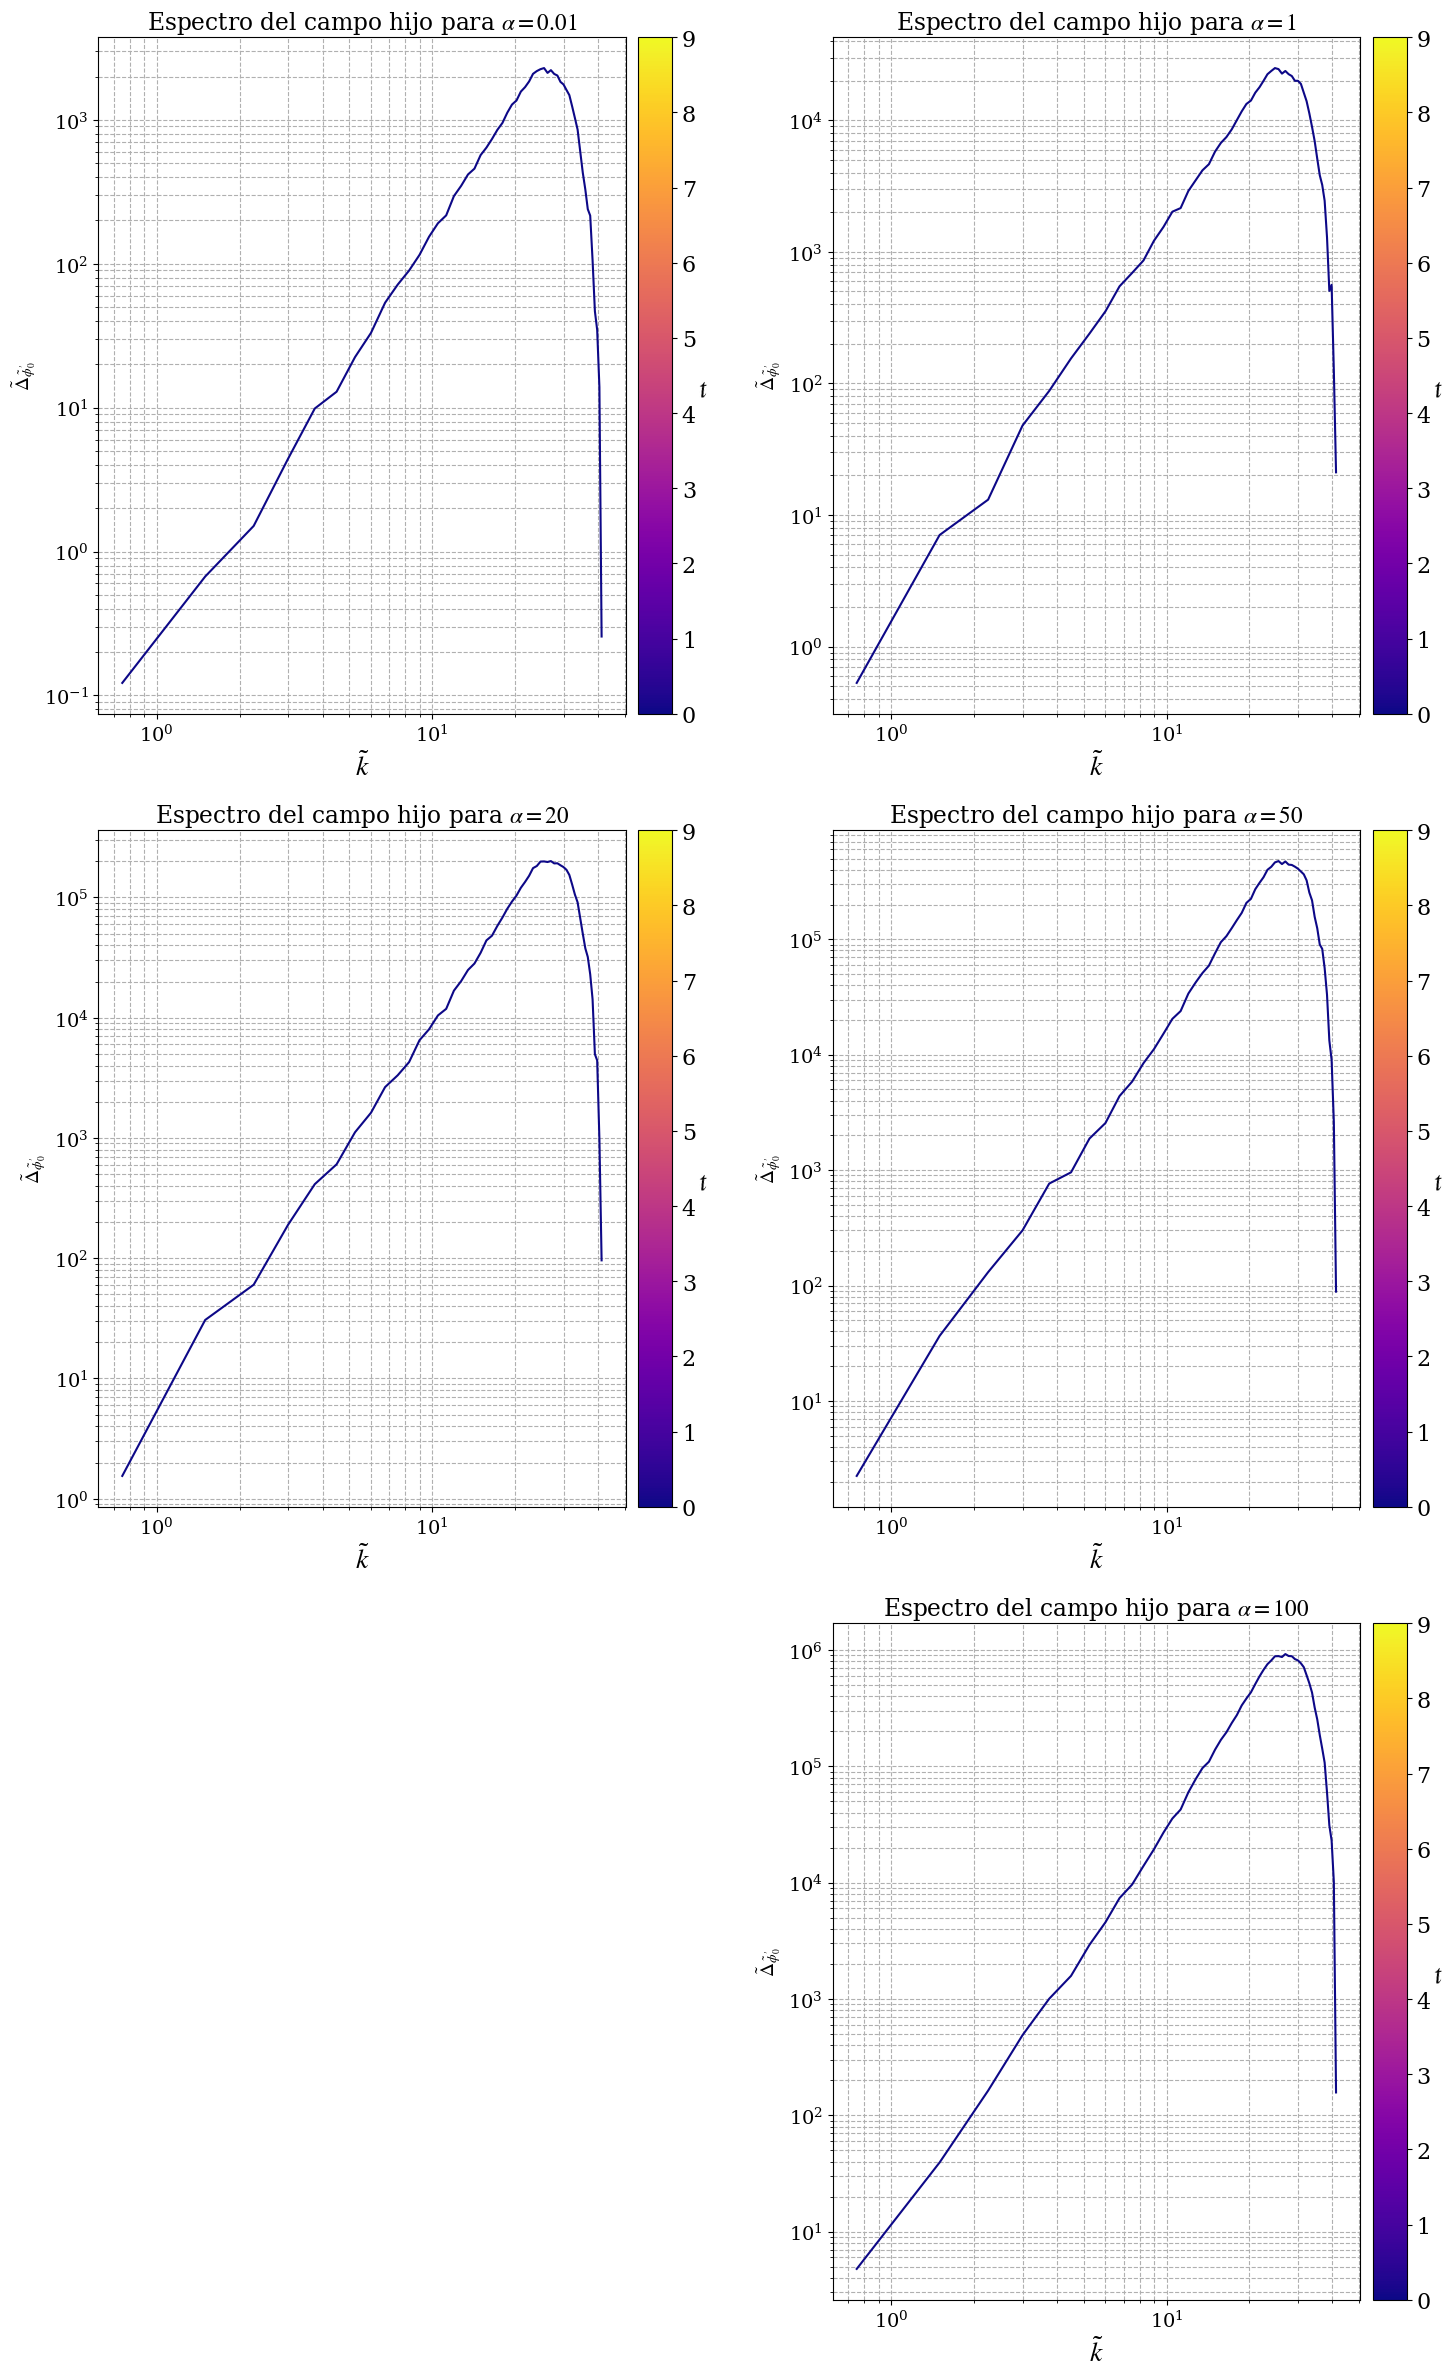

In [11]:
infSpa001, nBinsa001, nSpectraa001 = load_spectrum(dira001 + "spectra_scalar_1.txt")
infSpa1, nBinsa1, nSpectraa1 = load_spectrum(dira1 + "spectra_scalar_1.txt")
infSpa20, nBinsa20, nSpectraa20 = load_spectrum(dira20 + "spectra_scalar_1.txt")
infSpa50, nBinsa50, nSpectraa50 = load_spectrum(dira50 + "spectra_scalar_1.txt")
infSpa100, nBinsa100, nSpectraa100 = load_spectrum(dira100 + "spectra_scalar_1.txt")

plt.figure(figsize=(15, 24))

plt.subplot(3, 2, 1)
plot_spectrum(infSpa001, 2,  nBinsa001, nSpectraa001)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\alpha = 0.01$')

plt.subplot(3, 2, 2)
plot_spectrum(infSpa1, 2,  nBinsa1, nSpectraa1)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\alpha = 1$')

plt.subplot(3, 2, 3)
plot_spectrum(infSpa20, 2,  nBinsa20, nSpectraa20)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\alpha = 20$')

plt.subplot(3, 2, 4)
plot_spectrum(infSpa50, 2,  nBinsa50, nSpectraa50)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\alpha = 50$')

plt.subplot(3, 2, 6)
plot_spectrum(infSpa100, 2,  nBinsa100, nSpectraa100)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo hijo para $\alpha = 100$')

plt.tight_layout()
plt.show()

# GWs

/tmp/ipykernel_79529/3892628047.py:40: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


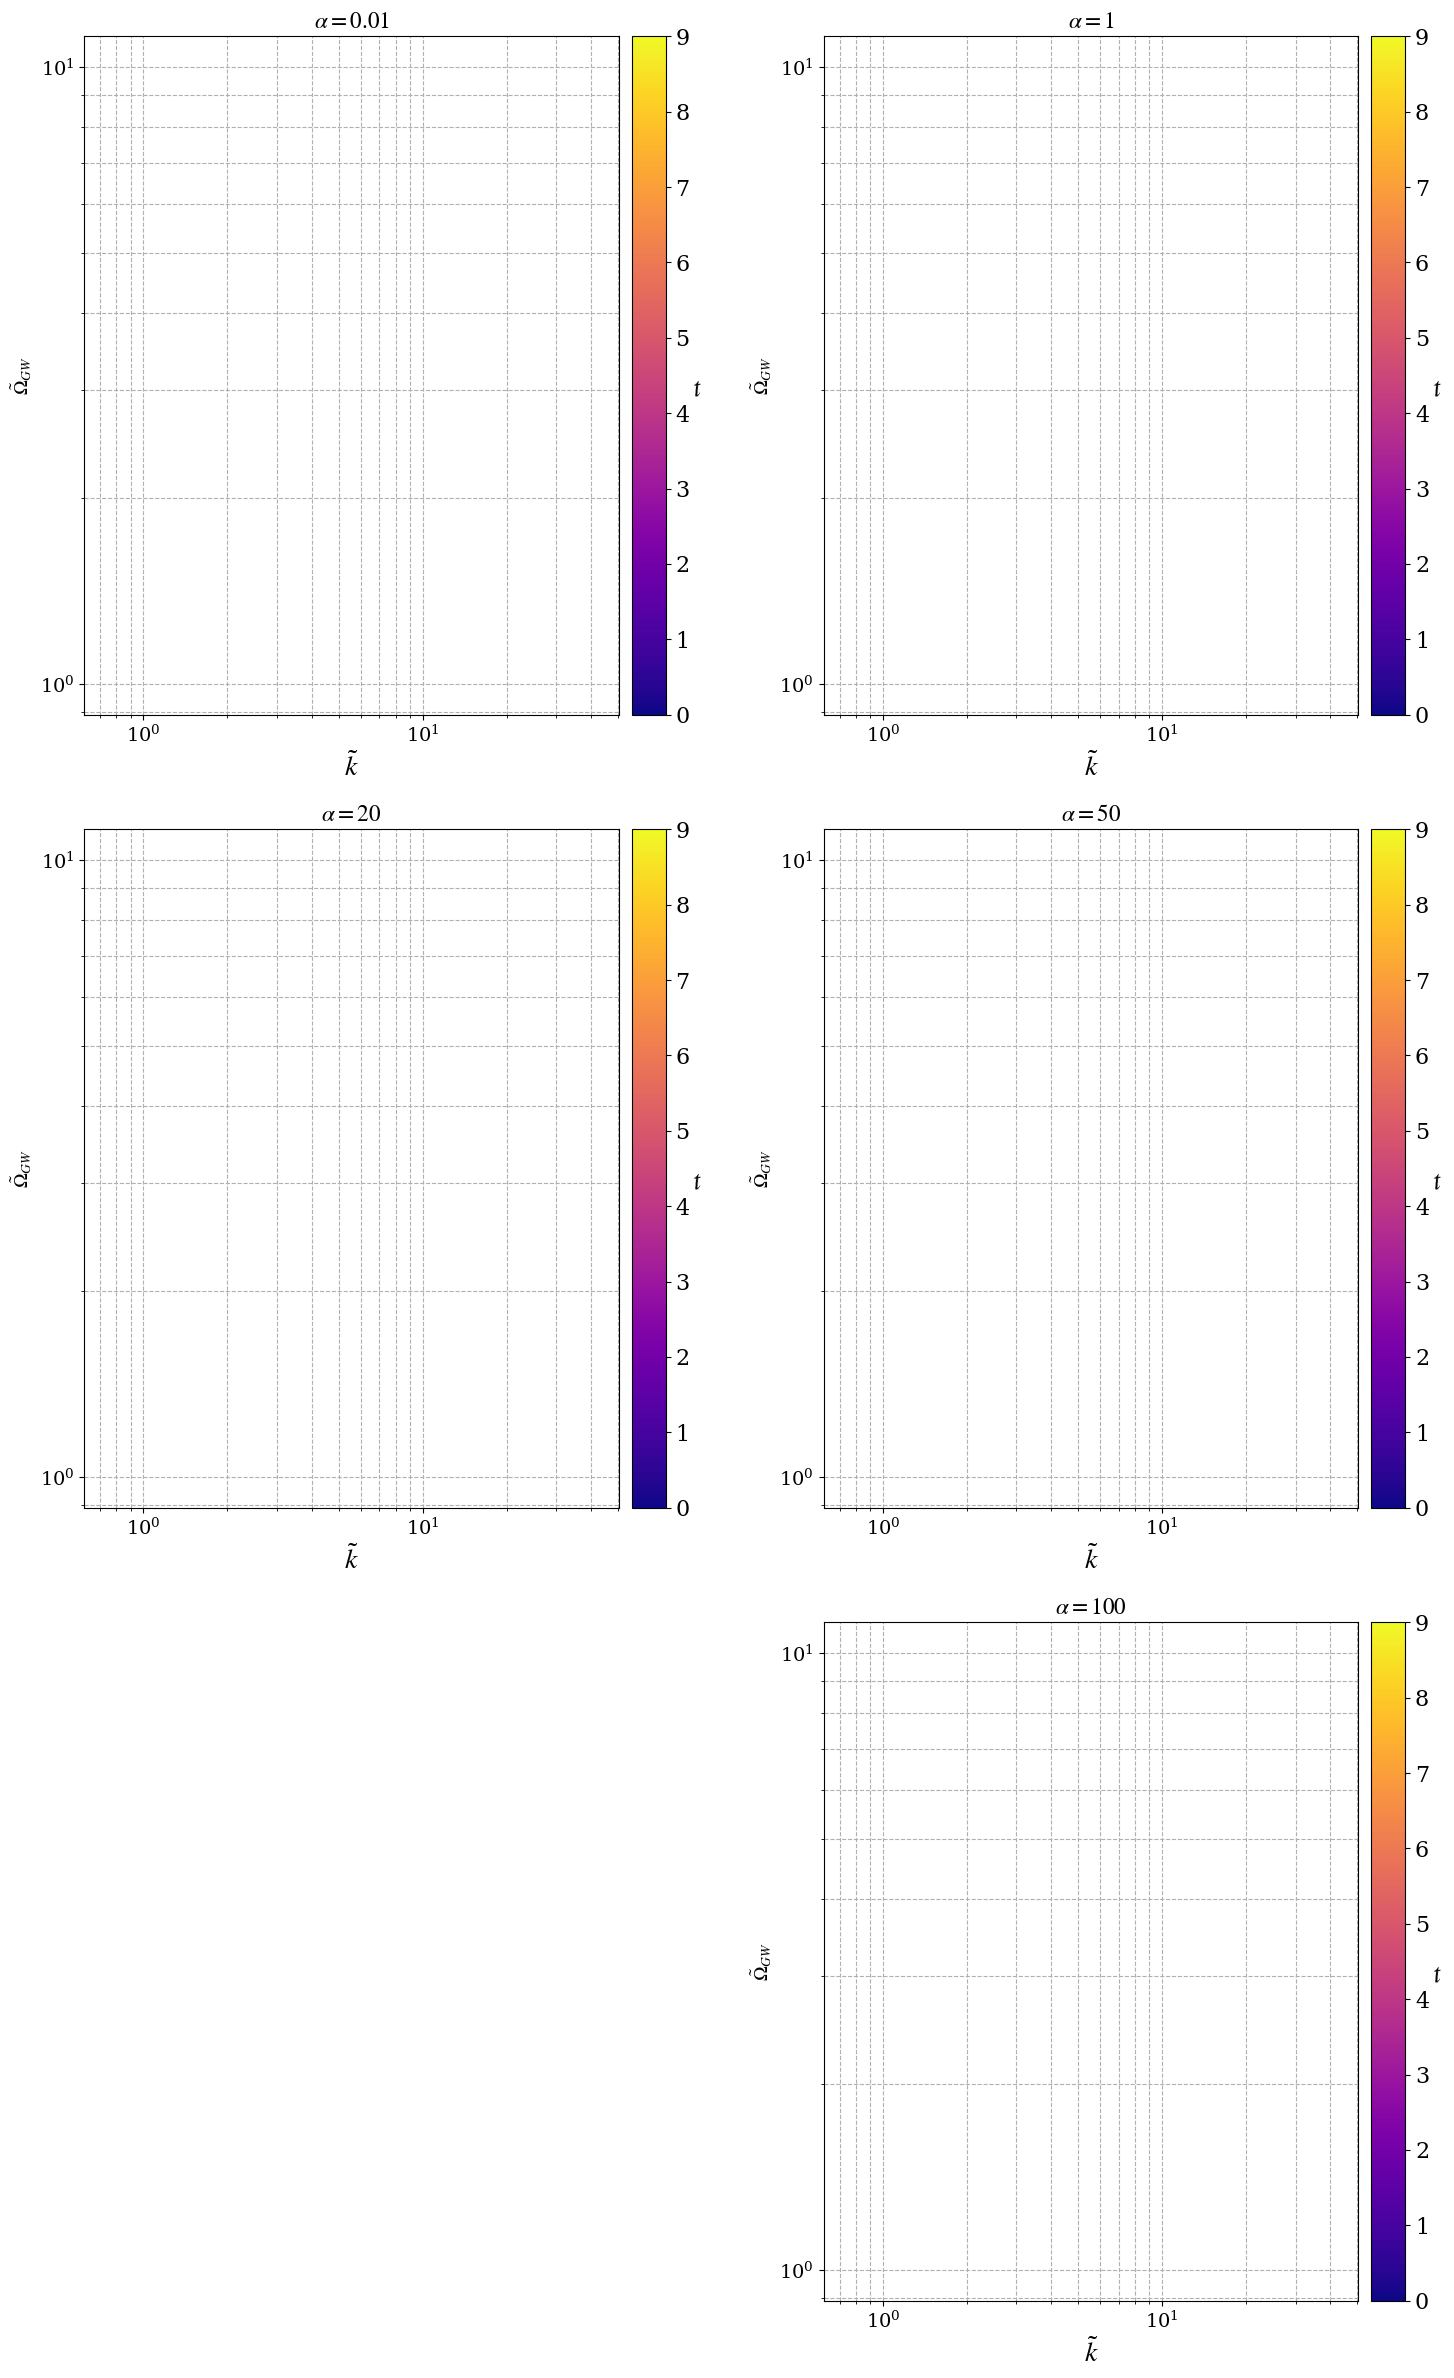

In [12]:
gwSpa001, nBinsa001, nSpectraa001 = load_spectrum(dira001 + "spectra_gws.txt")
gwSpa1, nBinsa1, nSpectraa1 = load_spectrum(dira1 + "spectra_gws.txt")
gwSpa20, nBinsa20, nSpectraa20 = load_spectrum(dira20 + "spectra_gws.txt")
gwSpa50, nBinsa50, nSpectraa50 = load_spectrum(dira50 + "spectra_gws.txt")
gwSpa100, nBinsa100, nSpectraa100 = load_spectrum(dira100 + "spectra_gws.txt")

plt.figure(figsize=(15, 24))

plt.subplot(3, 2, 1)
plot_spectrum(gwSpa001, 1,  nBinsa001, nSpectraa001)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\alpha = 0.01$')

plt.subplot(3, 2, 2)
plot_spectrum(gwSpa1, 1,  nBinsa1, nSpectraa1)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\alpha = 1$')

plt.subplot(3, 2, 3)
plot_spectrum(gwSpa20, 1,  nBinsa20, nSpectraa20)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\alpha = 20$')

plt.subplot(3, 2, 4)
plot_spectrum(gwSpa50, 1,  nBinsa50, nSpectraa50)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\alpha = 50$')

plt.subplot(3, 2, 6)
plot_spectrum(gwSpa100, 1,  nBinsa100, nSpectraa100)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\alpha = 100$')

plt.tight_layout()
plt.show()